In [1]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import harmless warnings
import warnings
warnings.filterwarnings('ignore')

# Notebook formatting
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
# Reading the data and first 5 columns
emp_data = pd.read_csv('employee_data.csv')
emp_data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
# Undersatnding the no of rows and columns
print(f'The employee data has {emp_data.shape[0]} rows and {emp_data.shape[1]} columns')

The employee data has 1470 rows and 35 columns


In [4]:
# Reading the last 5 columns
emp_data.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


In [5]:
# Unique columns
print(emp_data.columns.unique())

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [6]:
# Count all rows involved in duplication (including first occurrences)
total_duplicated_rows = len(emp_data[emp_data.duplicated(keep=False)])
total_duplicated_rows 

0

In [7]:
# Check if duplicate columns exist
has_duplicates = emp_data.shape[1] != emp_data.T.drop_duplicates().T.shape[1]

if has_duplicates:
    print("Duplicate columns found")
else:
    print("No duplicate columns found")

No duplicate columns found


In [8]:
# Number of categorical and numerical features
num, obj = 0,0

for cols in emp_data.columns:
    if emp_data[cols].dtypes == 'O':
        obj += 1
    else:
        num += 1
print(f'The no of numercial columns are {num} and categorical columns are {obj}')

The no of numercial columns are 26 and categorical columns are 9


In [9]:
# Checking the data type and missing values with sample
msg_dtype_df = pd.DataFrame({'Missing % of values' : round(emp_data.isnull().mean()*100, 2), 'Data Types' : emp_data.dtypes})
msg_dtype_df

# Sample data
sample_data =  pd.DataFrame(emp_data.head(2).T)

# Renaming sample columns
sample_data.rename(columns = {0 : 'Sample_1', 1: 'Sample_2'}, inplace = True)

# Concatenation
data_concat = pd.concat([msg_dtype_df, sample_data], axis = 1)

data_concat

,Missing % of values,Data Types,Sample_1,Sample_2
Age,0.0,int64,41,49
Attrition,0.0,object,Yes,No
BusinessTravel,0.0,object,Travel_Rarely,Travel_Frequently
DailyRate,0.0,int64,1102,279
Department,0.0,object,Sales,Research & Development
DistanceFromHome,0.0,int64,1,8
Education,0.0,int64,2,1
EducationField,0.0,object,Life Sciences,Life Sciences
EmployeeCount,0.0,int64,1,1
EmployeeNumber,0.0,int64,1,2


In [10]:
# No of attrition

emp_data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

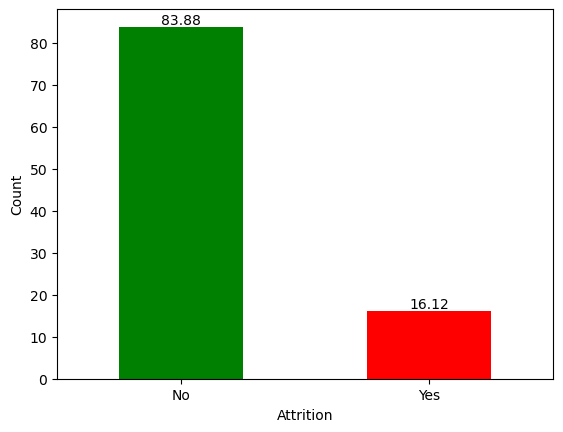

In [11]:
# Ploting the Attrition status graph as %

ax = round(emp_data['Attrition'].value_counts(normalize=True)*100,2).plot.bar(color = ['green', 'red'])
ax.bar_label(ax.containers[0])
ax.set_ylabel('Count')
plt.xticks(rotation = 0)
plt.show()

# Observation 1

In [12]:
# Missing column check

mv_great30_lst = []
mv_less30_lst = []

for feature in emp_data.columns:
    if round(emp_data[feature].isnull().mean()*100, 2) >= 30:
        mv_great30_lst.append(feature)
    elif 0.000 < round(emp_data[feature].isnull().mean()*100, 2) <= 30:
        mv_less30_lst.append(feature)
print(f'There are {len(mv_great30_lst)} features with missing values grater than 30%')
print(f'There are {len(mv_less30_lst)} features with missing values less than 30%')

There are 0 features with missing values grater than 30%
There are 0 features with missing values less than 30%


In [13]:
# looping to find attribute with one unique value

u_feat_lst_num = []
u_feat_lst_obj = []

for feature in emp_data.columns:
    if emp_data[feature].dtypes == 'O':
        if emp_data[feature].nunique() == 1:
            u_feat_lst_obj.append(feature)

    else:
        if emp_data[feature].nunique() == 1:
            u_feat_lst_num.append(feature)

print(f'The feature with only one unique value in numerical cols are {u_feat_lst_num}, and in object columns are {u_feat_lst_obj}')

The feature with only one unique value in numerical cols are ['EmployeeCount', 'StandardHours'], and in object columns are ['Over18']


In [14]:
# Checking if there exists any diff among 'DailyRate', 'HourlyRate', 'MonthlyRate', & 'MonthlyIncome'.

emp_data[['DailyRate', 'HourlyRate', 'MonthlyRate', 'MonthlyIncome']].head()

,DailyRate,HourlyRate,MonthlyRate,MonthlyIncome
0,1102,94,19479,5993
1,279,61,24907,5130
2,1373,92,2396,2090
3,1392,56,23159,2909
4,591,40,16632,3468


In [15]:
# Dropping unnecessary columns

emp_data.drop(columns = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber', 'DailyRate', 'HourlyRate', 'PerformanceRating'], axis = 1, inplace = True)

In [16]:
# No of rows and columns after first cleaning

print(f'The employee data has {emp_data.shape[0]} rows and {emp_data.shape[1]} columns')

The employee data has 1470 rows and 28 columns


# Observation 2

# Univariate Analysis

## For Numerical Column

In [17]:
# Numerical Columns

num_list = []
for feature in emp_data:
    if emp_data[feature].dtypes != 'O':
        num_list.append(feature)
print(num_list)

['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


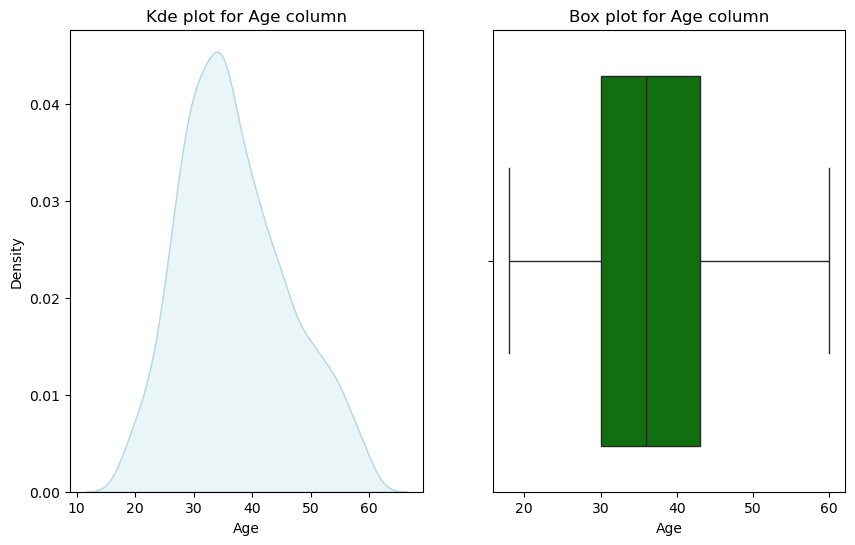

In [18]:
# Understanding the distribution for Age column

figs, axes = plt.subplots(1,2, figsize=(10,6))
for ax in axes:
    sns.kdeplot(x = emp_data['Age'], fill = True, color = 'lightblue', ax=axes[0])
    axes[0].set_title('Kde plot for Age column')
    sns.boxplot(emp_data['Age'], orient = 'h', color = 'green', ax=axes[1])
    axes[1].set_title('Box plot for Age column')
    plt.show()

In [19]:
emp_data['Age'].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

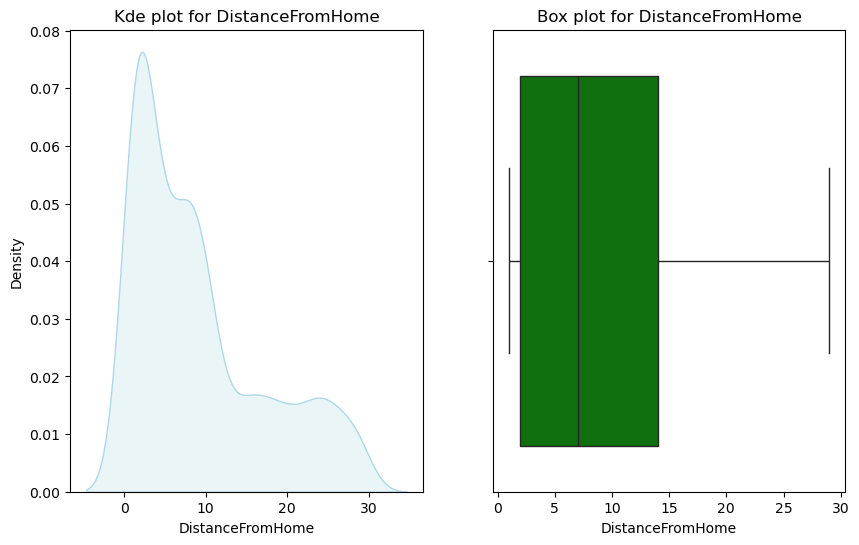

In [20]:
# Understanding the distribution for DistanceFromHome

figs, axes = plt.subplots(1,2, figsize=(10,6))
for ax in axes:
    sns.kdeplot(x = emp_data['DistanceFromHome'], fill = True, color = 'lightblue', ax=axes[0])
    axes[0].set_title('Kde plot for DistanceFromHome')
    sns.boxplot(emp_data['DistanceFromHome'], orient = 'h', color = 'green', ax=axes[1])
    axes[1].set_title('Box plot for DistanceFromHome')
    plt.show()

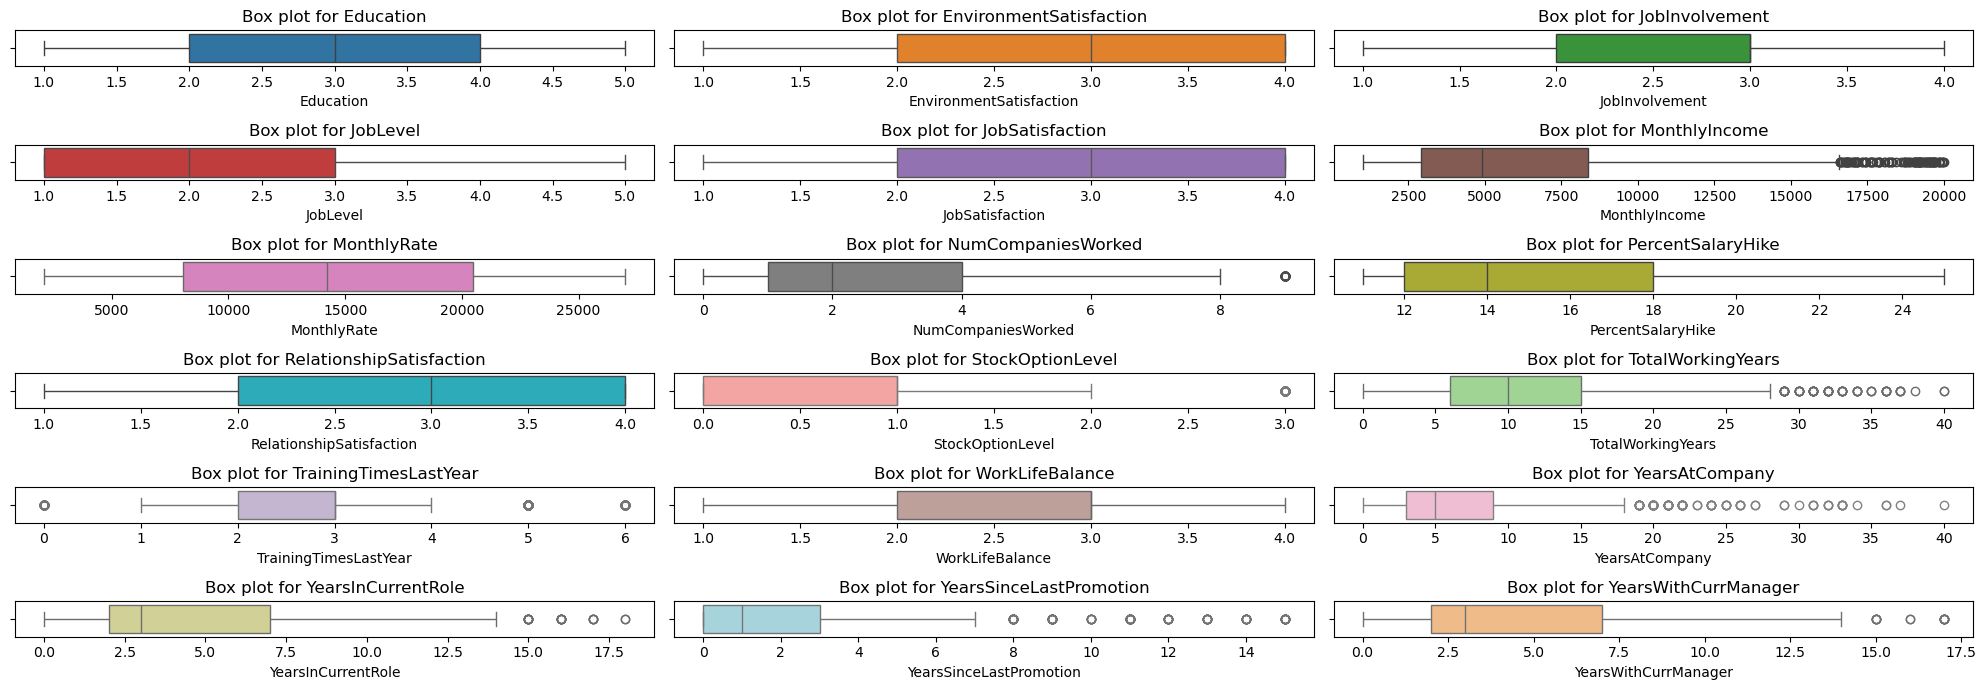

In [21]:
# Understanding the boc for other Numerical cols

fig, axes = plt.subplots(6,3, figsize=(20,7))
axes = axes.flatten()
features = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 
 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 
 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 
 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # teal
    '#ff9896',  # light red
    '#98df8a',  # light green
    '#c5b0d5',  # light purple
    '#c49c94',  # light brown
    '#f7b6d2',  # light pink
    '#dbdb8d',  # light olive
    '#9edae5',  # light teal
    '#ffbb78'   # light orange
]

for ax, feature, color in zip(axes, features, colors):
    # Boxplot for numerical features
    sns.boxplot(emp_data[feature], color=color, ax=ax, orient = 'h')
    ax.set_title(f'Box plot for {feature}')
plt.tight_layout()
plt.show()

In [22]:
# Statistical summary for interest rate

print('Statistical summary for Monthly Income:','\n')
print(emp_data['MonthlyIncome'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.1]))

Statistical summary for Monthly Income: 

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
10%       2317.600000
25%       2911.000000
50%       4919.000000
75%       8379.000000
90%      13775.600000
95%      17821.350000
99%      19626.310000
max      19999.000000
Name: MonthlyIncome, dtype: float64


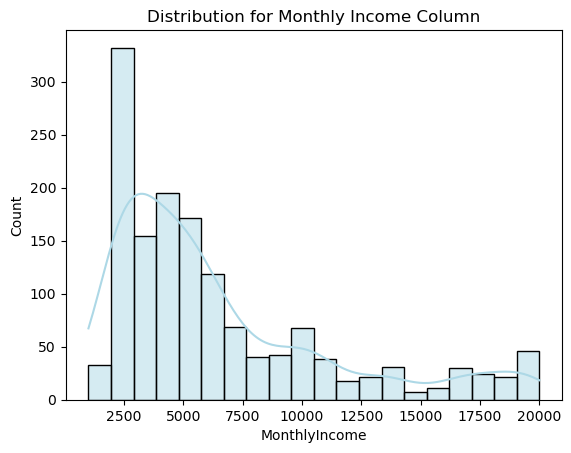

In [23]:
# Understanding Monthly Income Distribution

ax = sns.histplot(x = emp_data['MonthlyIncome'], fill = True, kde = True, color = 'lightblue')
ax.set_title('Distribution for Monthly Income Column')
plt.show()

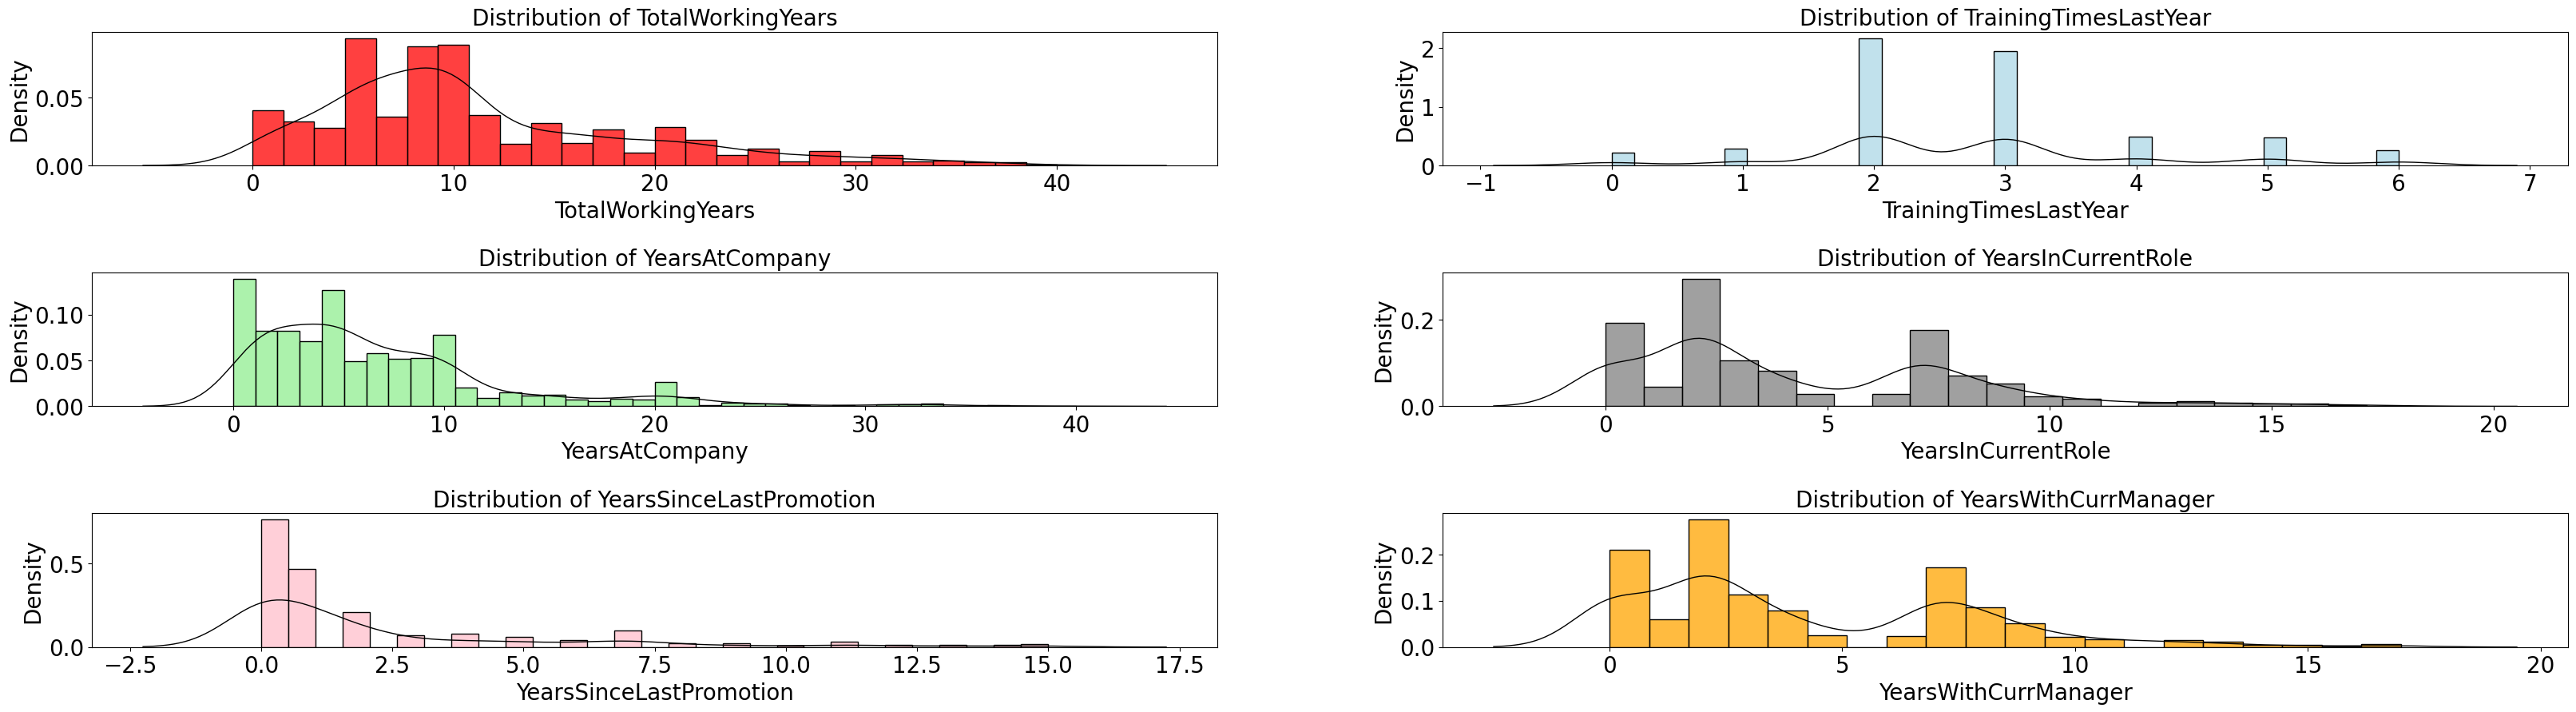

In [24]:
# Understanding the features with outliers using histogram

fig, axes = plt.subplots(3, 2, figsize=(40, 10), facecolor="white")
plt.subplots_adjust(hspace=0.8)
axes = axes.flatten()

# Features and colors
features = ['TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
colors   = ['red', 'lightblue', 'lightgreen', 'grey', 'pink', 'orange']

# Loop through features and plot
for ax, feature, color in zip(axes, features, colors):
    
    # Histogram (normalized to density so KDE matches)
    sns.histplot(emp_data[feature], stat="density", color=color, ax=ax, fill=True)
    
    # KDE curve (black line)
    sns.kdeplot(emp_data[feature], color="black", ax=ax, linewidth=1)
    
    ax.set_title(f'Distribution of {feature}', fontsize=20)
    ax.set_xlabel(feature, fontsize=20)
    ax.set_ylabel('Density', fontsize=20)
    ax.tick_params(axis='both', labelsize=20)

plt.show()

## For Object Column

In [25]:
# Object Columns

obj_list = []
for feature in emp_data:
    if emp_data[feature].dtypes == 'O':
        obj_list.append(feature)
print(obj_list)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


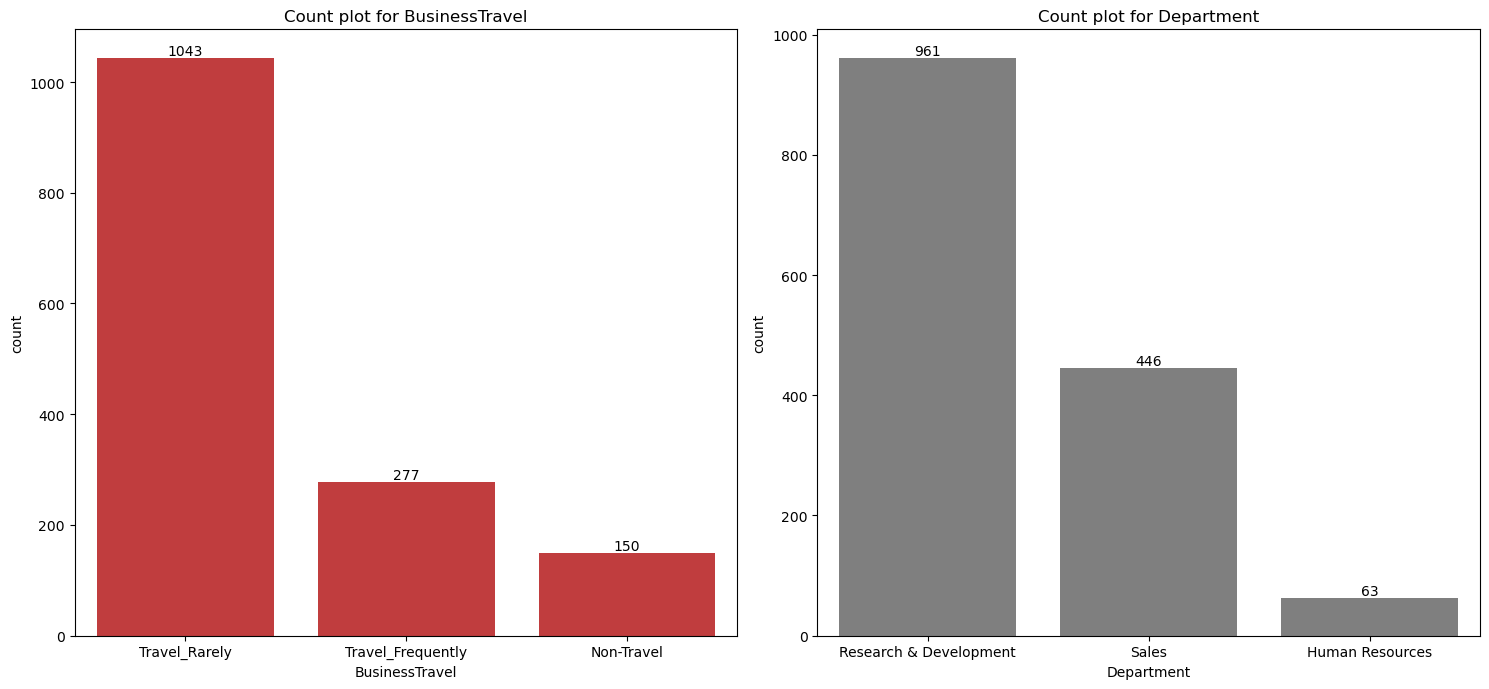

In [26]:
# Understanding the count plot for 'BusinessTravel', & 'Department' cols

fig, axes = plt.subplots(1,2, figsize=(15,7))
features = ['BusinessTravel', 'Department']
colors = ['#d62728', '#7f7f7f']

for ax, feature, color in zip(axes, features, colors):
    # Boxplot for numerical features
    sns.countplot(x=emp_data[feature], order = emp_data[feature].value_counts().index, color=color, ax=ax, orient = 'h')
    ax.bar_label(ax.containers[0])
    ax.set_title(f'Count plot for {feature}')
plt.tight_layout()
plt.show()

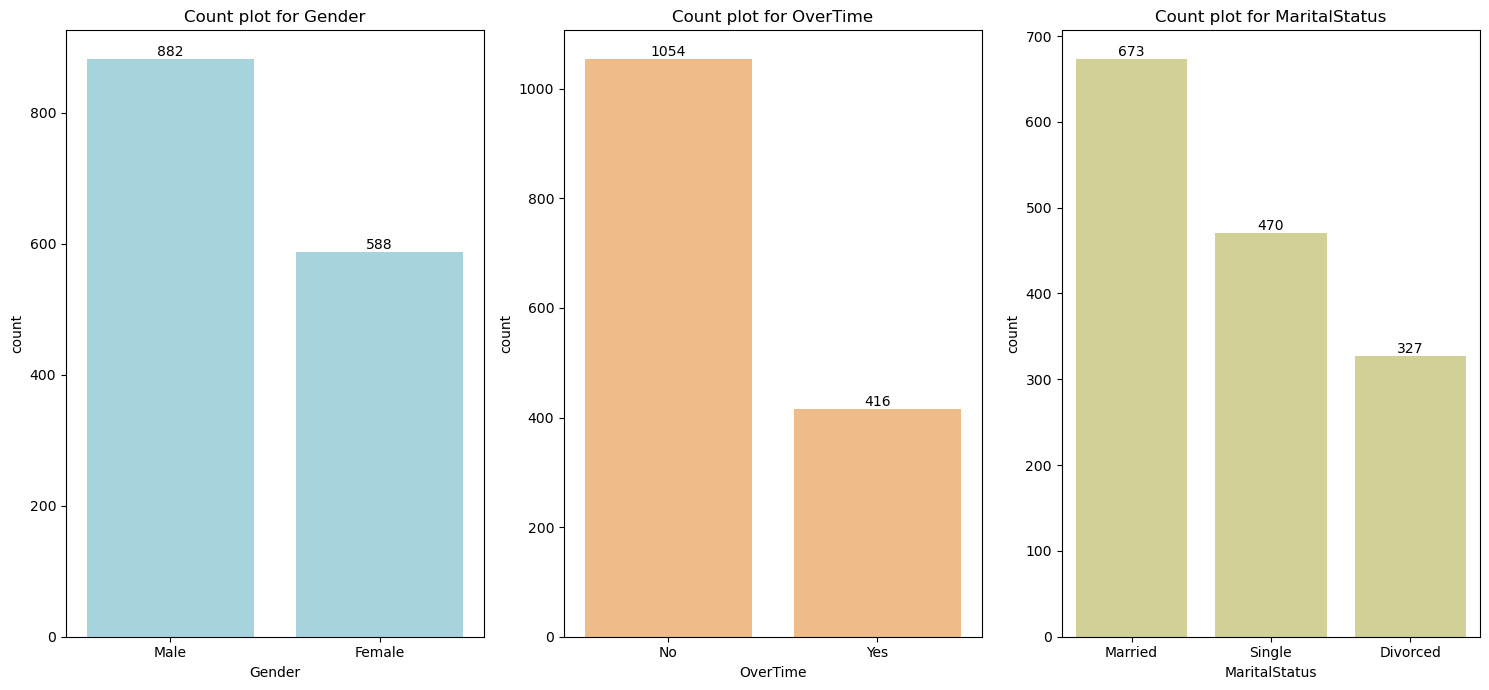

In [27]:
# Understanding the count plot for 'Gender', 'OverTime', 'MaritalStatus'

fig, axes = plt.subplots(1,3, figsize=(15,7))
features = ['Gender', 'OverTime', 'MaritalStatus']
colors = ['#9edae5', '#ffbb78', '#dbdb8d']

for ax, feature, color in zip(axes, features, colors):
    # Boxplot for numerical features
    sns.countplot(x=emp_data[feature], order = emp_data[feature].value_counts().index, color=color, ax=ax, orient = 'h')
    ax.bar_label(ax.containers[0])
    ax.set_title(f'Count plot for {feature}')
plt.tight_layout()
plt.show()

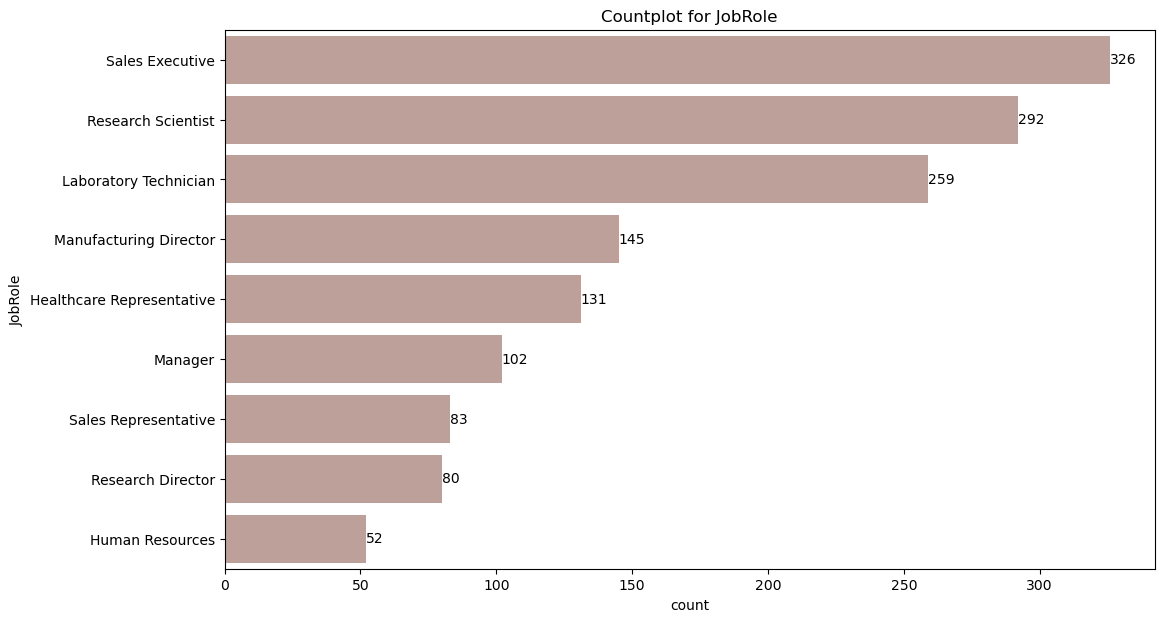

In [28]:
# Countplot for JobRole
plt.figure(figsize=(12, 7))
ax = sns.countplot(y = emp_data['JobRole'], order = emp_data['JobRole'].value_counts().index, color=  '#c49c94')
ax.set_title('Countplot for JobRole')
ax.bar_label(ax.containers[0])
plt.show()

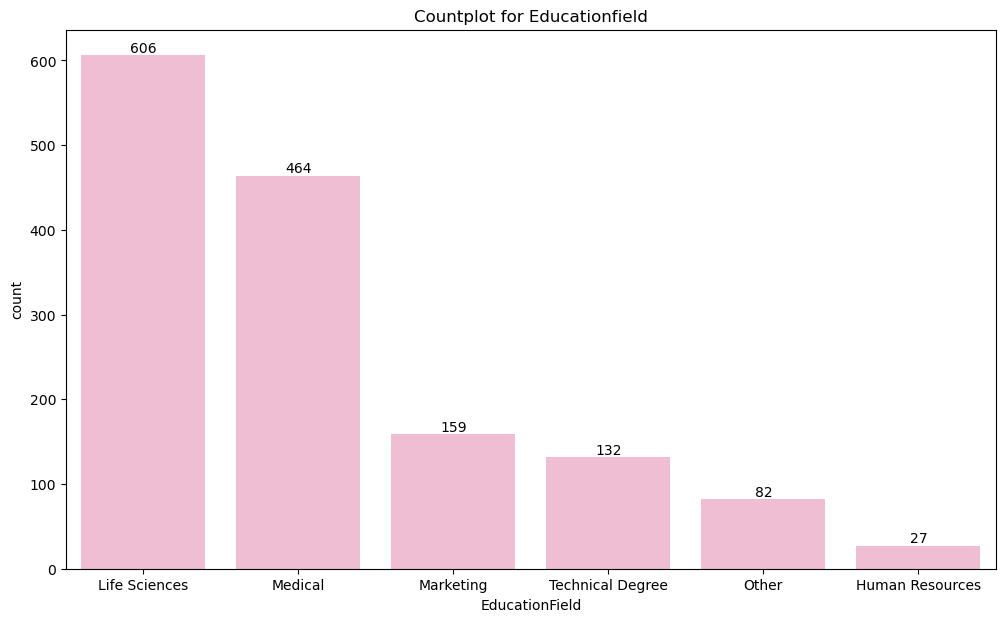

In [29]:
# Countplot for JobRole
plt.figure(figsize=(12, 7))
ax = sns.countplot(x = emp_data['EducationField'], order = emp_data['EducationField'].value_counts().index, color= '#f7b6d2')
ax.set_title('Countplot for Educationfield')
ax.bar_label(ax.containers[0])
plt.show()

# Observation on Univariate Analysis

# Multivariate Analysis

In [30]:
# Creating a new dataframe that has only "Attrited" employees data

co_data = emp_data[emp_data['Attrition'] == 'Yes']
co_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,1,0,8,0,1,6,4,0,5
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,2,0,7,3,3,0,0,0,0
14,28,Yes,Travel_Rarely,Research & Development,24,3,Life Sciences,3,Male,2,1,Laboratory Technician,3,Single,2028,12947,5,Yes,14,2,0,6,4,3,4,2,0,3
21,36,Yes,Travel_Rarely,Sales,9,4,Life Sciences,3,Male,2,1,Sales Representative,1,Single,3407,6986,7,No,23,2,0,10,4,3,5,3,0,3
24,34,Yes,Travel_Rarely,Research & Development,6,1,Medical,2,Male,3,1,Research Scientist,1,Single,2960,17102,2,No,11,3,0,8,2,3,4,2,1,3


In [31]:
# Co_data shapeo
co_data.shape

(237, 28)

## Categorical v/s Categorical(Target)

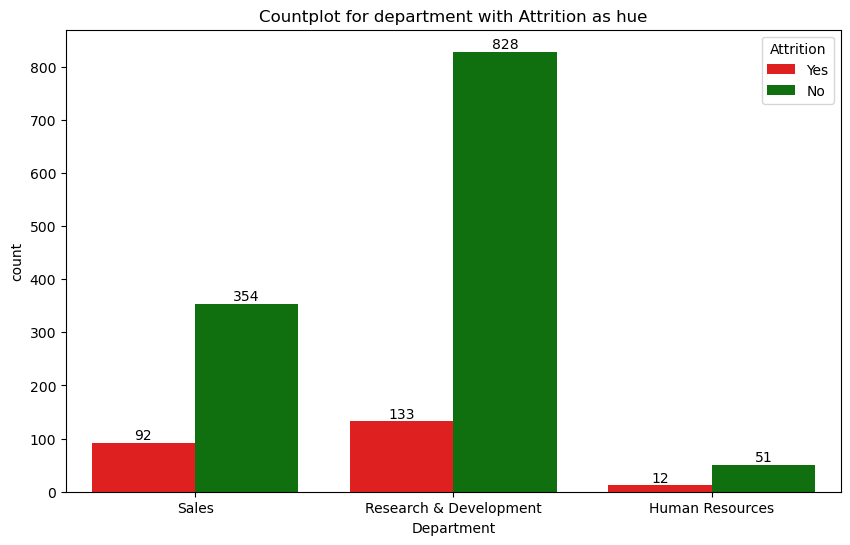

In [32]:
# Countplot for department with Attrition as hue

plt.figure(figsize=(10,6))
ax = sns.countplot(x = emp_data['Department'], palette={'Yes': 'red', 'No': 'green'}, hue = emp_data['Attrition'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Countplot for department with Attrition as hue')
plt.show()

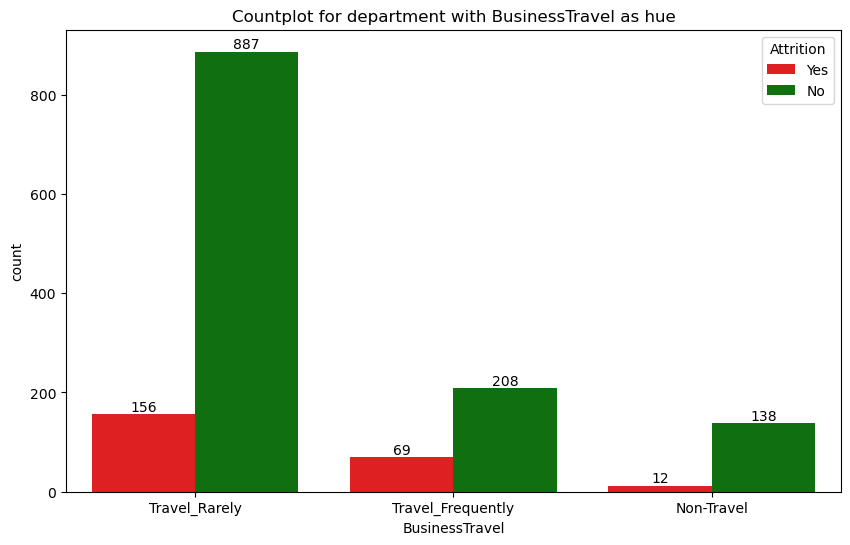

In [33]:
# Countplot for BusinessTravel with Attrition as hue

plt.figure(figsize=(10,6))
ax = sns.countplot(x=emp_data['BusinessTravel'], palette = {'Yes': 'red', 'No' : 'green'}, hue = emp_data['Attrition'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Countplot for BusinessTravel as hue')
plt.show()

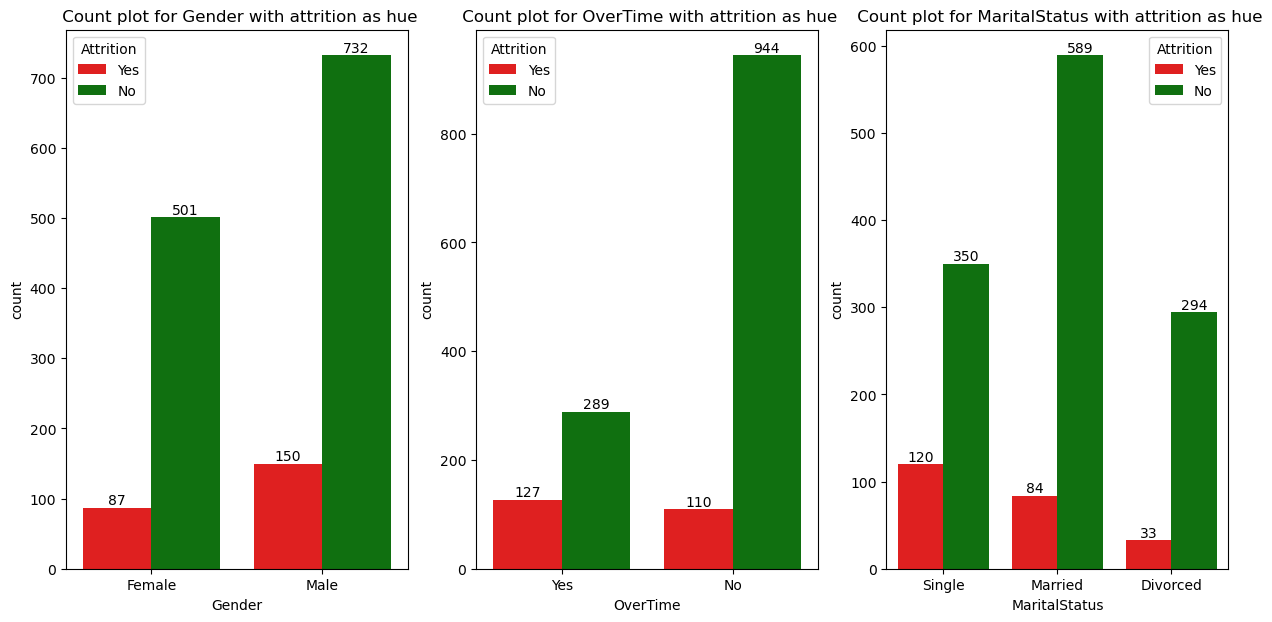

In [34]:
# Countplot for 'Gender', 'MaritalStatus', 'OverTime' with Attrition as hue

fig, axes = plt.subplots(1,3,figsize=(15,7))
faetures = ['Gender', 'MaritalStatus', 'OverTime']
for ax, feature in zip(axes, features):
    sns.countplot(x = emp_data[feature], hue = emp_data['Attrition'], palette = {'Yes' : 'red', 'No' : 'green'}, ax = ax)
    ax.bar_label(ax.containers[0])
    ax.bar_label(ax.containers[1])
    ax.set_title(f' Count plot for {feature} with attrition as hue')
plt.show()

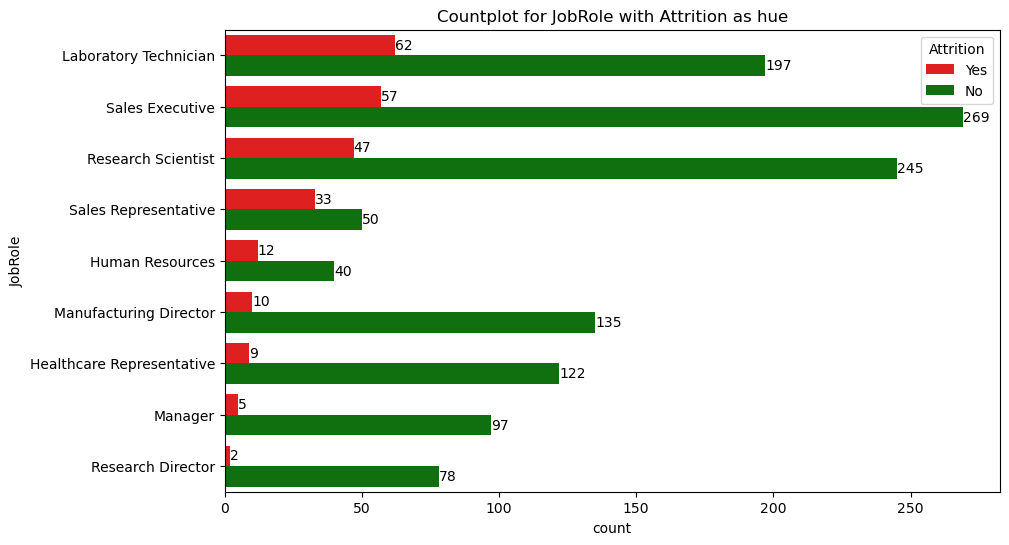

In [35]:
# Countplot for JobRole with Attrition as hue

plt.figure(figsize=(10,6))
ax = sns.countplot(y=emp_data['JobRole'], palette = {'Yes': 'red', 'No' : 'green'}, hue = emp_data['Attrition'], order = co_data['JobRole'].value_counts().index)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Countplot for JobRole with Attrition as hue')
plt.show()

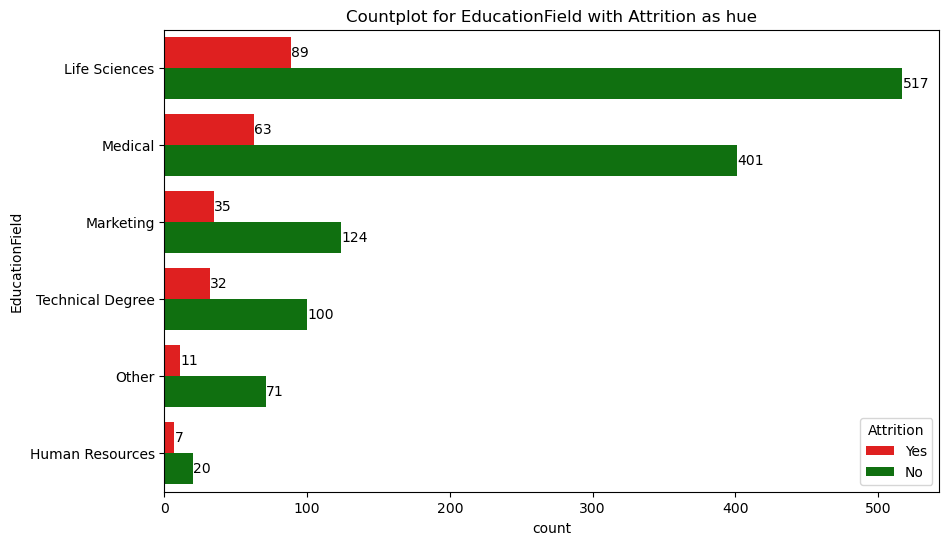

In [36]:
# Countplot for EducationField with Attrition as hue

plt.figure(figsize=(10,6))
ax = sns.countplot(y=emp_data['EducationField'], palette = {'Yes': 'red', 'No' : 'green'}, hue = emp_data['Attrition'], order = co_data['EducationField'].value_counts().index)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Countplot for EducationField with Attrition as hue')
plt.show()

In [38]:
num_list

['Age',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## Numerical v/s Categorical(Target)

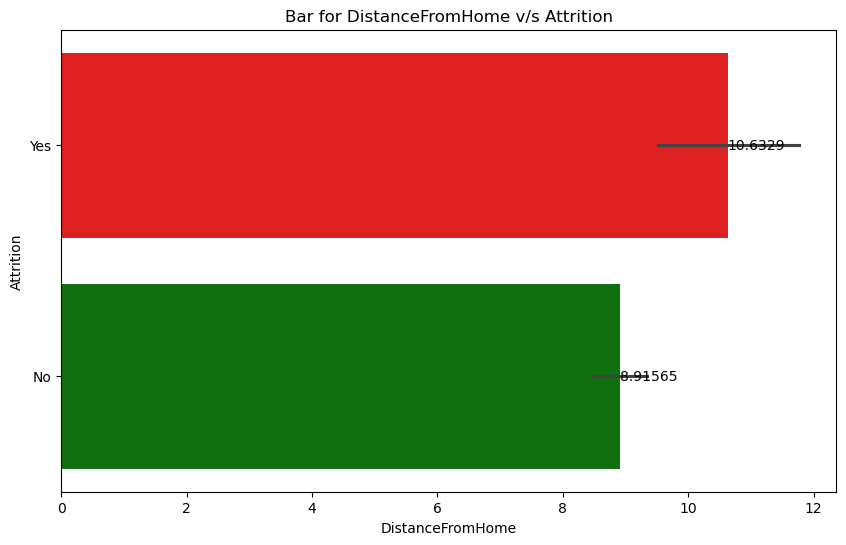

In [39]:
# Barplot for DistanceFromHome v/s Attrition 

plt.figure(figsize=(10,6))
ax = sns.barplot(emp_data, x = 'DistanceFromHome', y = 'Attrition', palette=['red', 'green'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Bar for DistanceFromHome v/s Attrition')
plt.show()

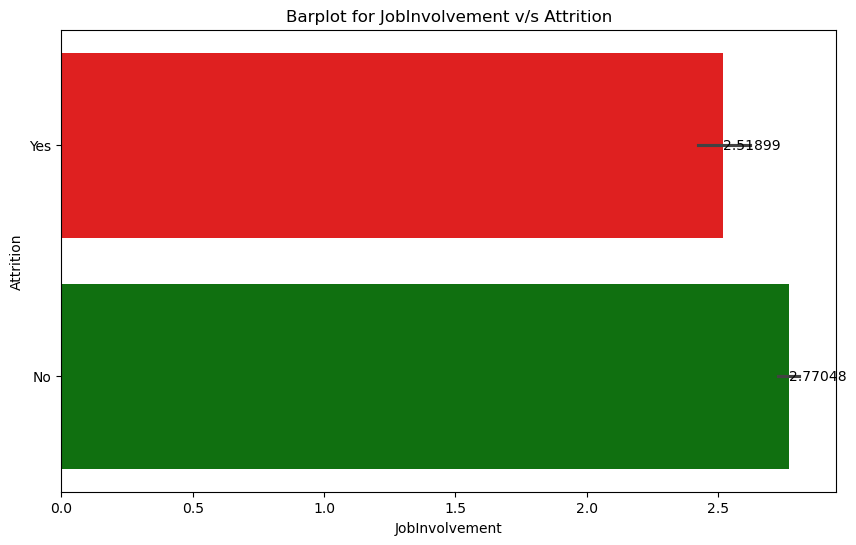

In [40]:
# 'Barplot for JobInvolvement v/s Attrition

plt.figure(figsize=(10,6))
ax = sns.barplot(emp_data, x = 'JobInvolvement', y = 'Attrition', palette=['red', 'green'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Barplot for JobInvolvement v/s Attrition')
plt.show()

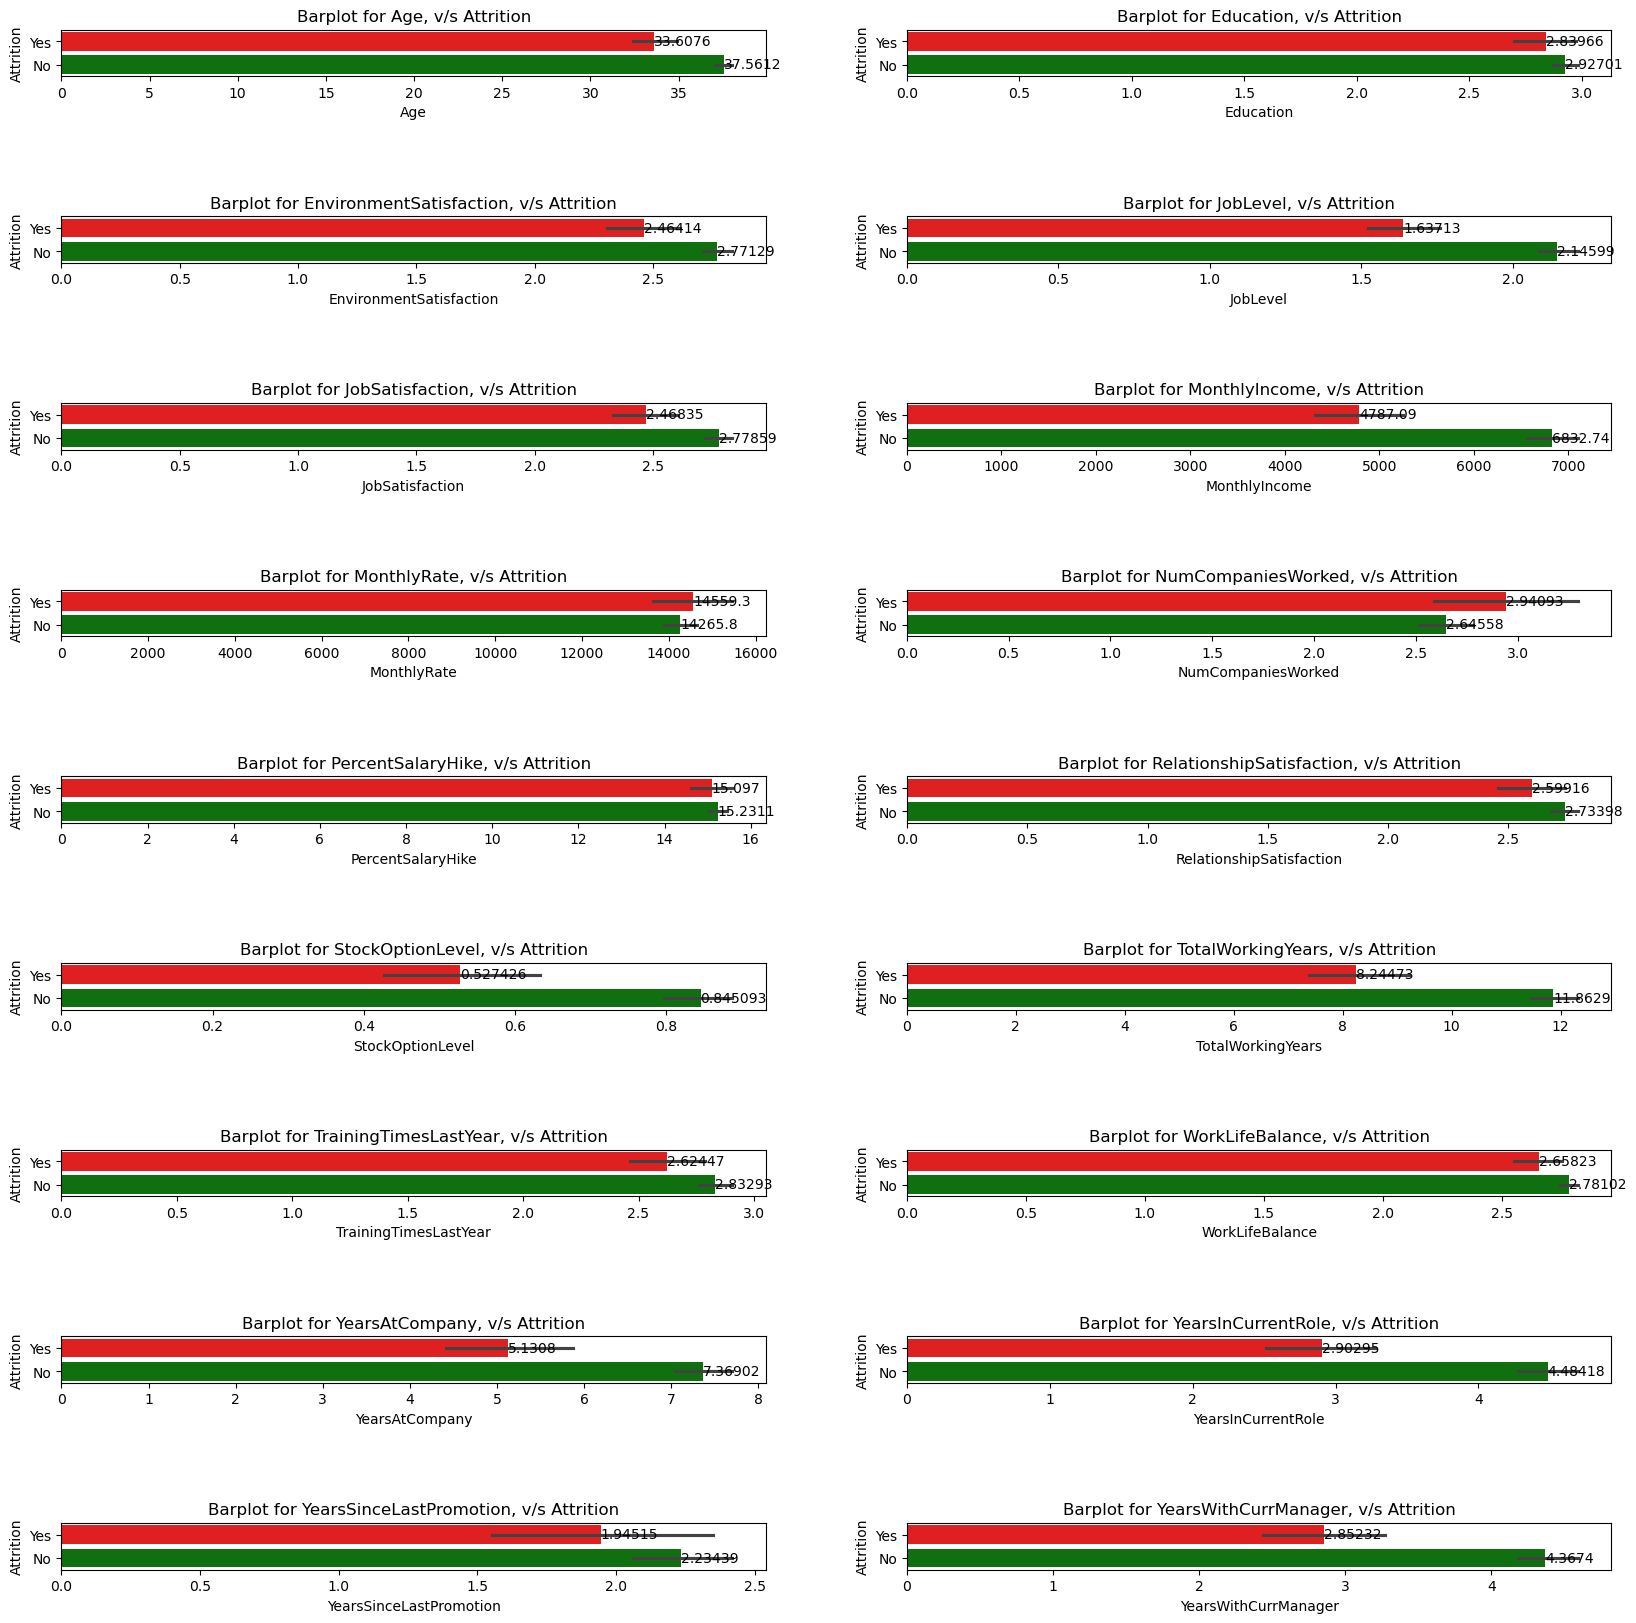

In [41]:
#Barplot for numerical v/s target column

fig, axes = plt.subplots(9,2, figsize=(20,20))
plt.subplots_adjust(hspace=3)
axes = axes.flatten()
features = ['Age',
 'Education',
 'EnvironmentSatisfaction',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

for ax, feature in zip(axes, features):
    sns.barplot(x = emp_data[feature], y = emp_data['Attrition'], palette = ['red', 'green'], ax=ax)
    ax.bar_label(ax.containers[0])
    ax.bar_label(ax.containers[1])
    ax.set_title(f'Barplot for {feature}, v/s Attrition')
plt.show()

In [42]:
obj_list

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

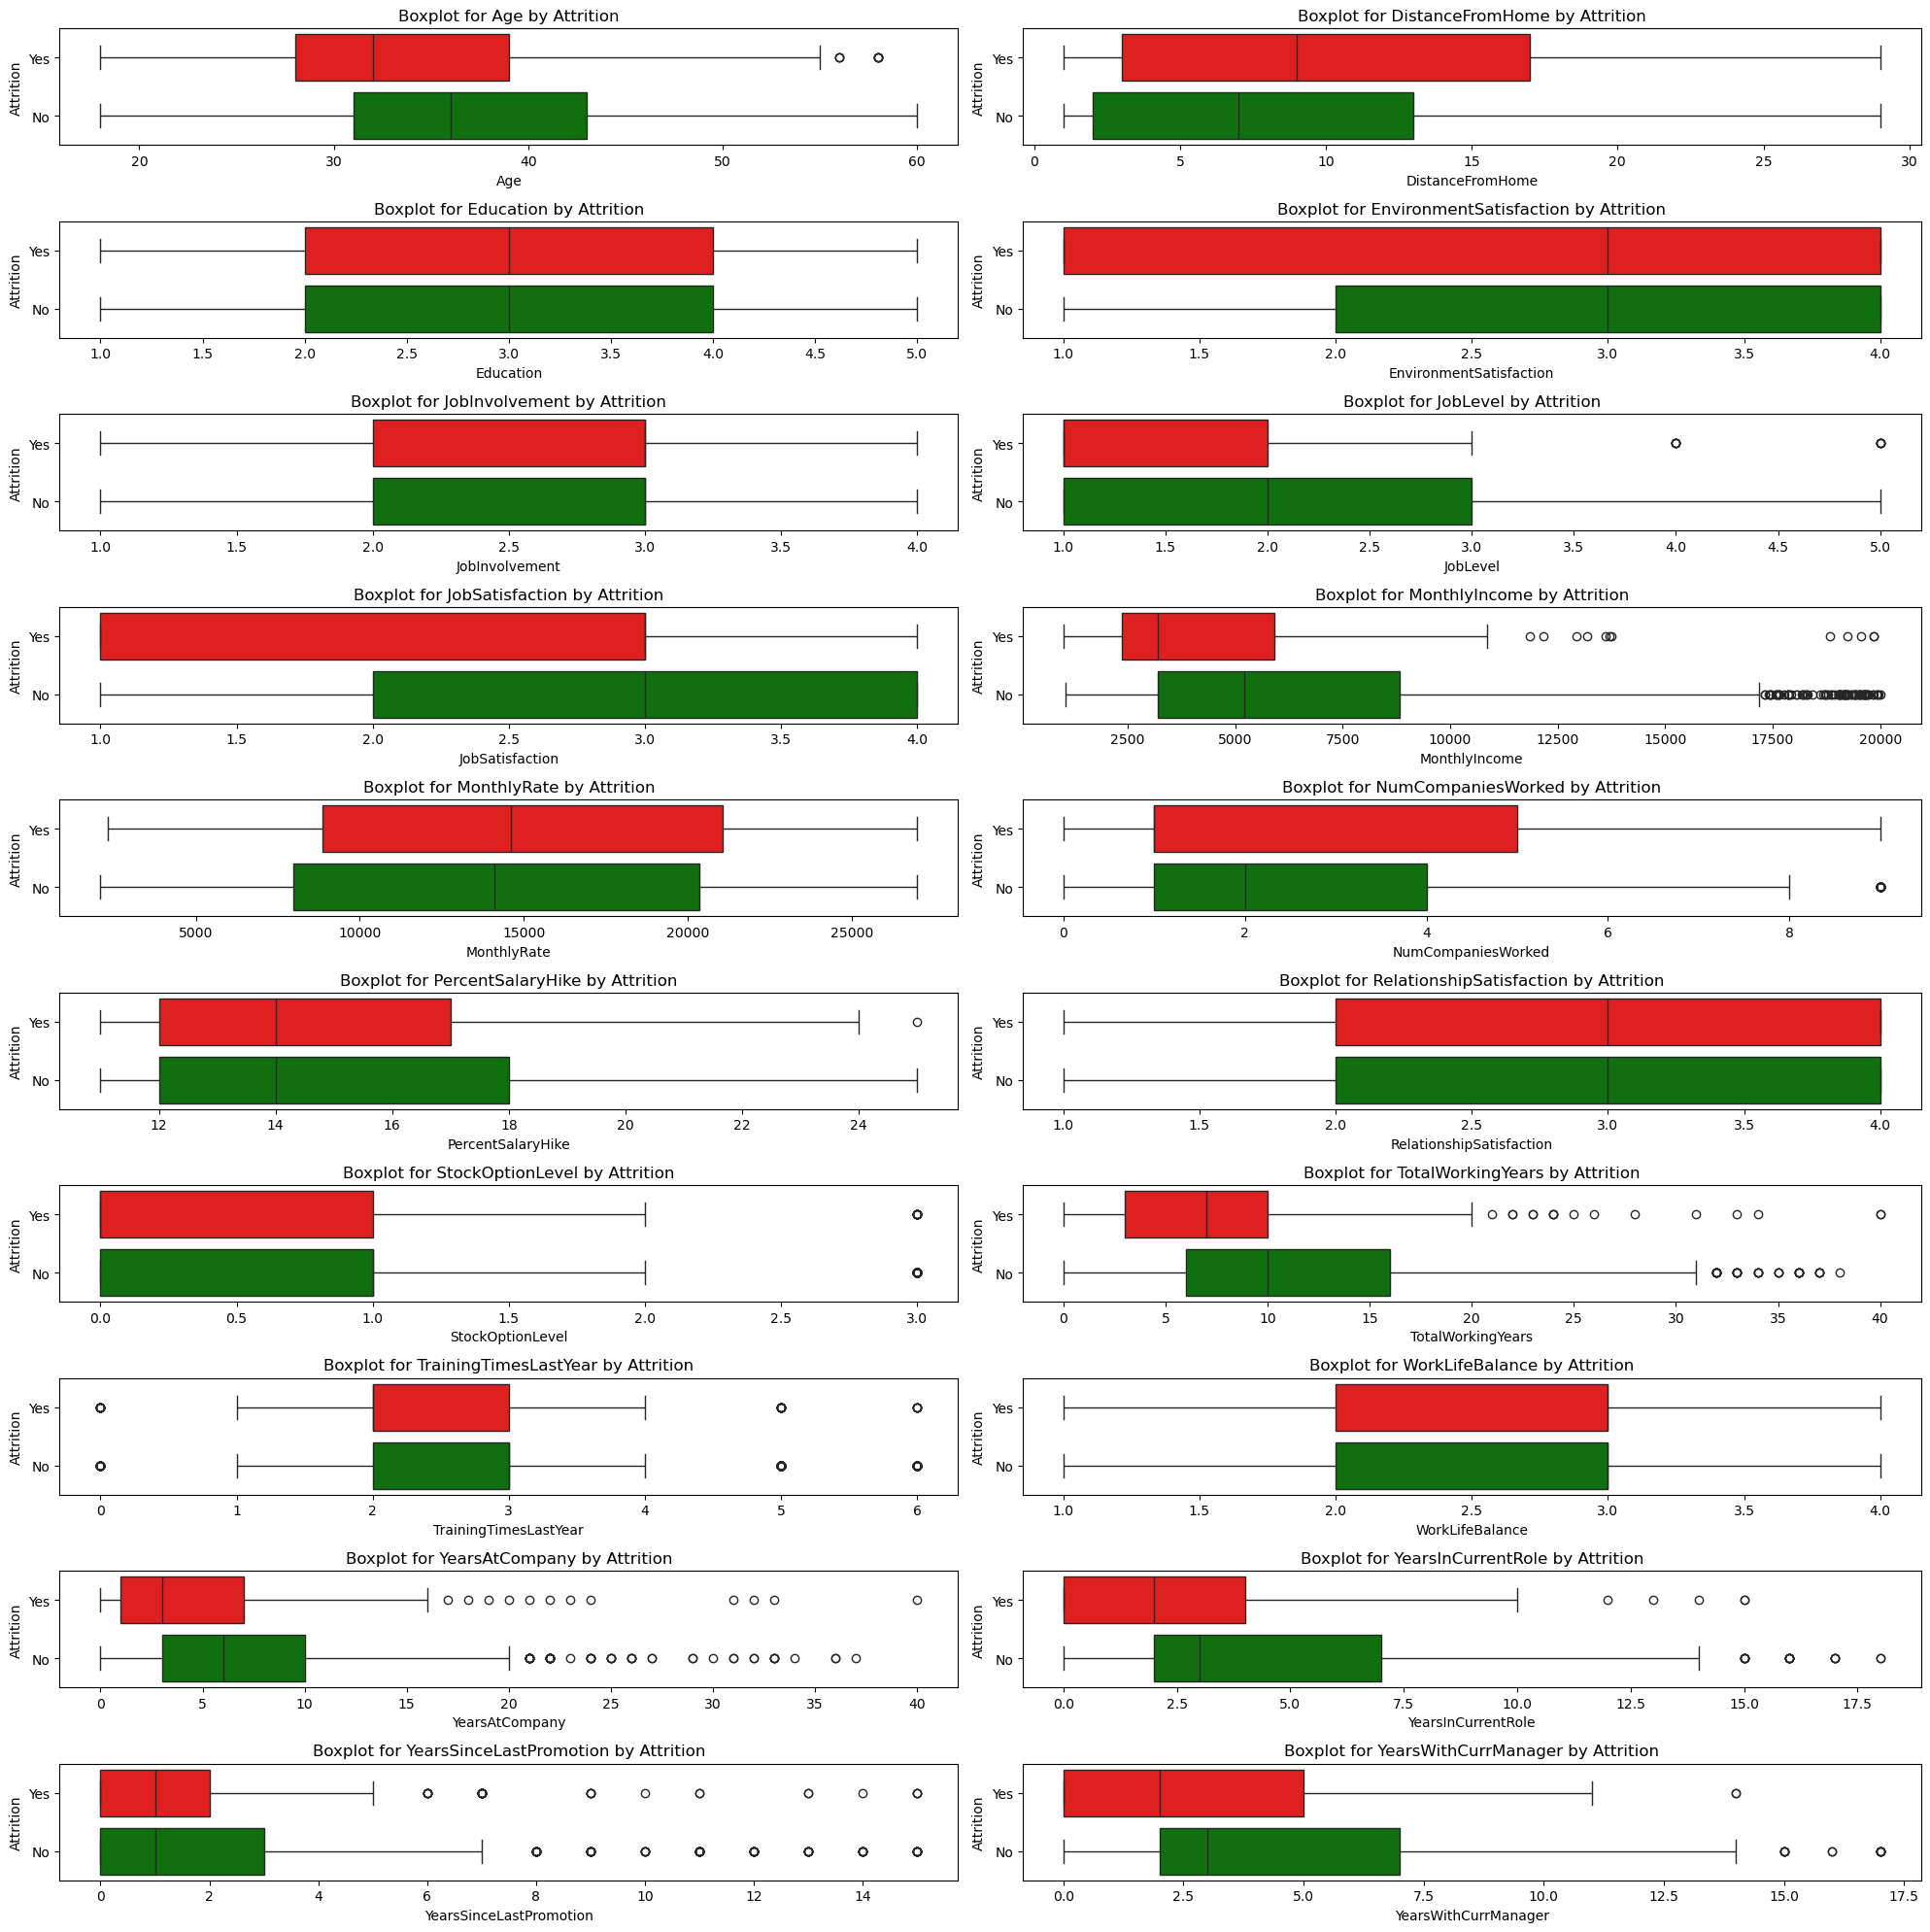

In [43]:
#Boxplot for numerical v/s target column

# First, ensure all Department values are properly mapped
# Check if there are any unmapped values
mapping = {'Research & Development': 'R&D', 'Human Resources': 'HR', 'Sales': 'Sales'}  # Added Sales explicitly
co_data['Department'] = co_data['Department'].map(mapping)
emp_data['Department'] = emp_data['Department'].map(mapping)

fig, axes = plt.subplots(10, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=3)
axes = axes.flatten()
features = ['Age',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

for ax, feature in zip(axes, features):
    # Use hue instead of y for categorical comparison in boxplot
    sns.boxplot(data = emp_data, y='Attrition',x=feature, ax=ax, palette = ['red', 'green'])
    ax.set_title(f'Boxplot for {feature} by Attrition')
    ax.set_xlabel(feature)
    ax.set_ylabel('Attrition')


# Save the figure as PNG with high resolution
plt.savefig('department_features_boxplotsvsattrition.png', dpi=300, bbox_inches='tight')

plt.tight_layout()  # Better spacing
plt.show()

# Observations from Boxplots (Attrition vs Numerical Features)

## Numerical v/s Numerical

In [ ]:
# cor-coeff for entire dataframe

corr = emp_data.corr(numeric_only=True)
corr

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.001686,0.208034,0.010146,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.003634,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DistanceFromHome,-0.001686,1.000000,0.021042,-0.016075,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,0.021042,1.000000,-0.027128,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.011111,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,-0.016075,-0.027128,1.000000,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,-0.031701,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
JobInvolvement,0.029820,0.008783,0.042438,-0.008278,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.017205,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.005303,0.101589,0.001212,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,-0.034730,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,-0.003669,-0.011296,-0.006784,-0.021476,-0.001944,1.000000,-0.007157,0.000644,-0.055699,0.020002,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,-0.017014,0.094961,-0.006259,-0.015271,0.950300,-0.007157,1.000000,0.034814,0.149515,-0.027269,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079
MonthlyRate,0.028051,0.027473,-0.026084,0.037600,-0.016322,0.039563,0.000644,0.034814,1.000000,0.017521,-0.006429,-0.004085,-0.034323,0.026442,0.001467,0.007963,-0.023655,-0.012815,0.001567,-0.036746
NumCompaniesWorked,0.299635,-0.029251,0.126317,0.012594,0.015012,0.142501,-0.055699,0.149515,0.017521,1.000000,-0.010238,0.052733,0.030075,0.237639,-0.066054,-0.008366,-0.118421,-0.090754,-0.036814,-0.110319


In [45]:
num_list

['Age',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

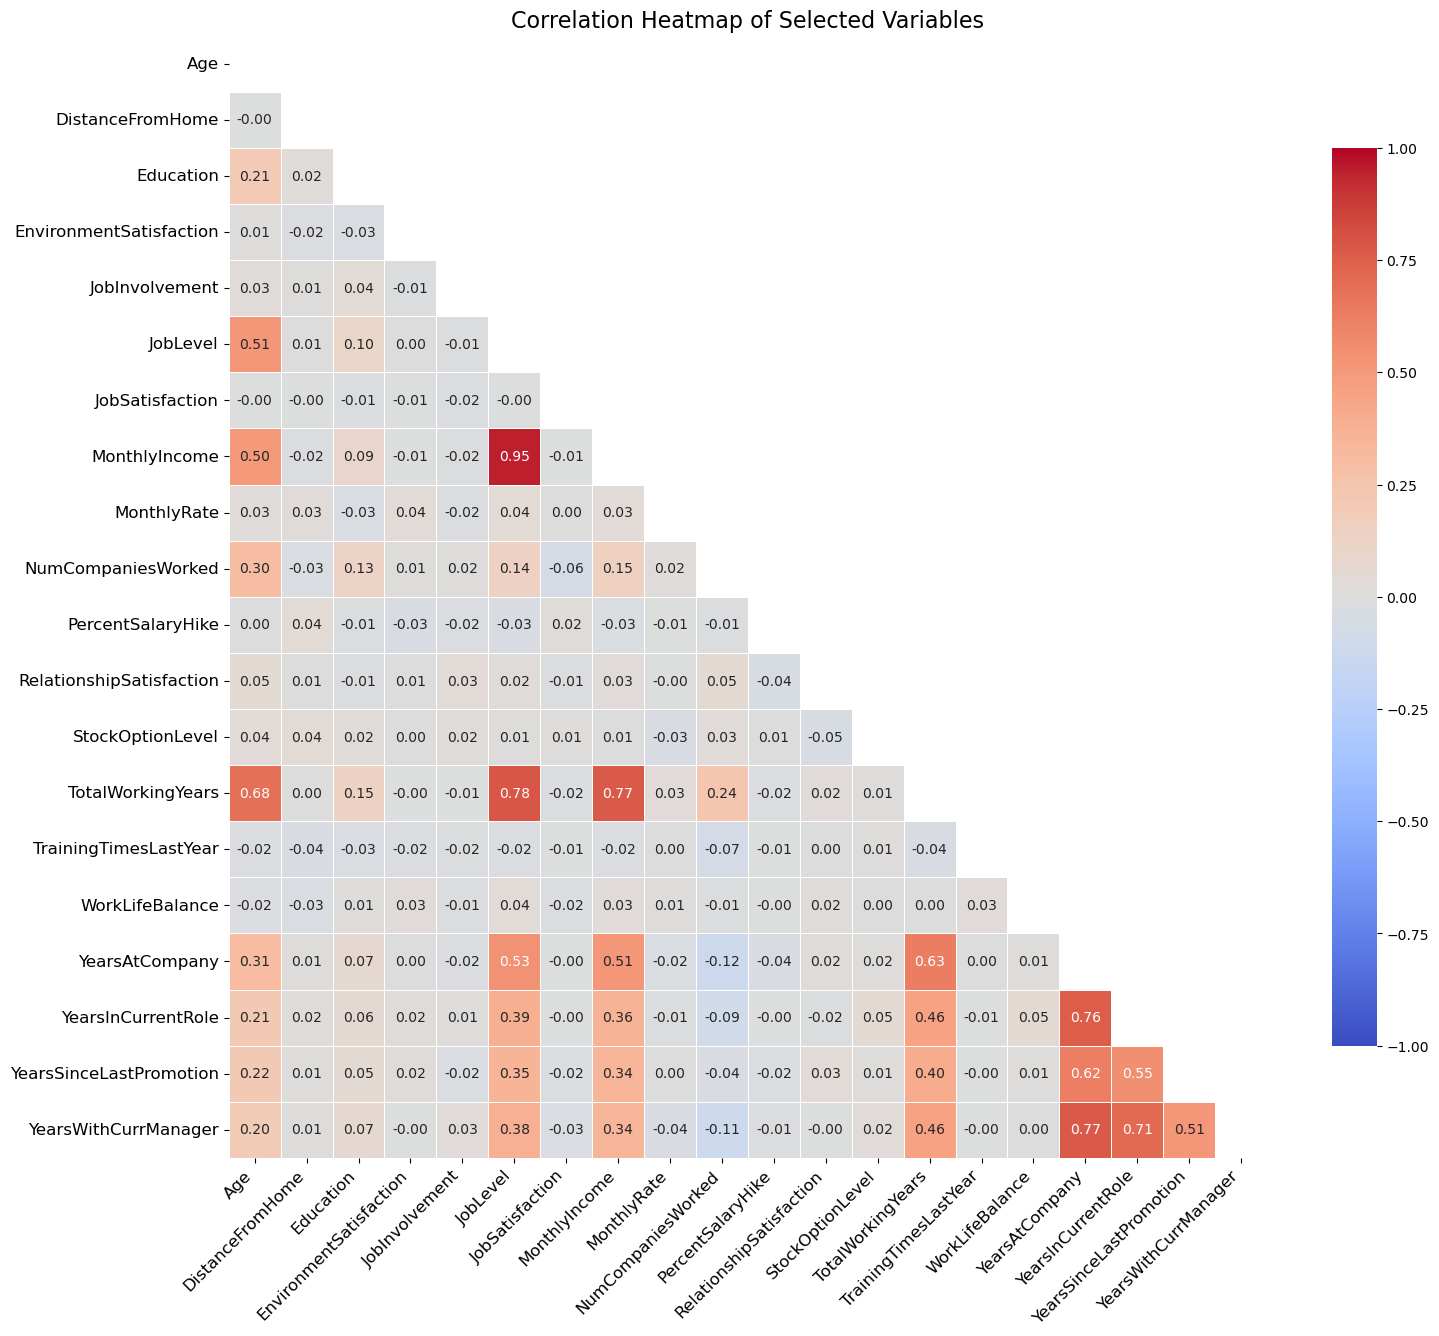

In [46]:
# Improved heatmap for better visibility

plt.figure(figsize=(16, 14))  # Even larger figure size

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Enhanced heatmap
sns.heatmap(
    corr,
    annot=True,               # Show correlation values
    fmt=".2f",                # Format to 2 decimal places
    cmap='coolwarm',          # Alternative high-contrast colormap
    vmin=-1, vmax=1,          # Full correlation range
    mask=mask,                # Hide upper triangle
    annot_kws={"size": 10},   # Larger annotation text
    linewidths=0.5,           # Add cell borders
    cbar_kws={"shrink": 0.8}  # Adjust colorbar size
)

plt.title('Correlation Heatmap of Selected Variables', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Larger x labels
plt.yticks(fontsize=12)  # Larger y labels

# Save the figure as PNG with high resolution
plt.savefig('numerical_features_correlation.png', dpi=300, bbox_inches='tight')

# Adjust layout
plt.tight_layout(pad=3)
plt.show()

## Multivariate Analysis

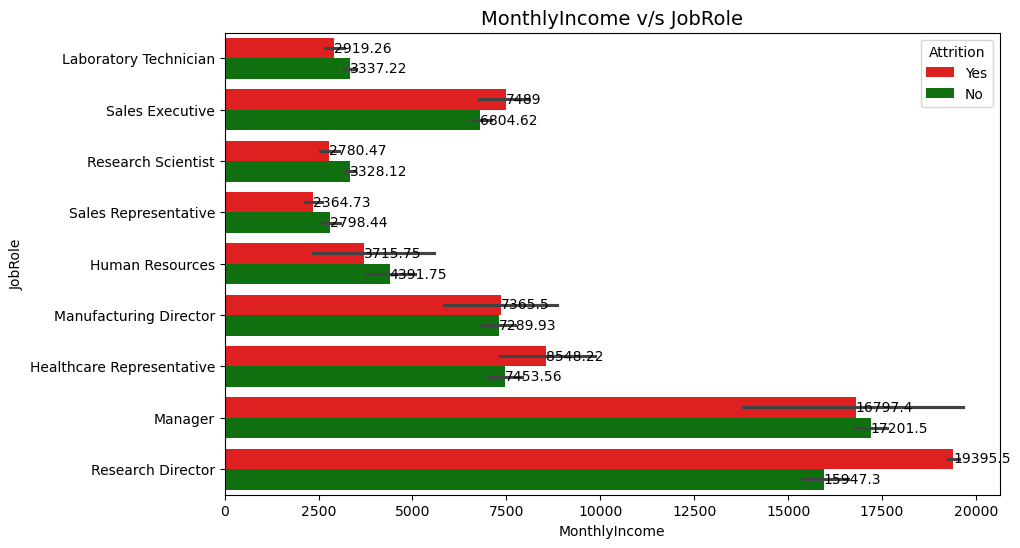

In [48]:
# Bar plot for monthly income by job role

fig,ax = plt.subplots(1,1, figsize=(10,6))
ax = sns.barplot(emp_data, x = 'MonthlyIncome', y = 'JobRole', palette = {'Yes': 'red', 'No' : 'green'}, hue = emp_data['Attrition'], order = co_data['JobRole'].value_counts().index)
ax.set_title('MonthlyIncome v/s JobRole',fontsize=14,color='black')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

In [47]:
obj_list

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

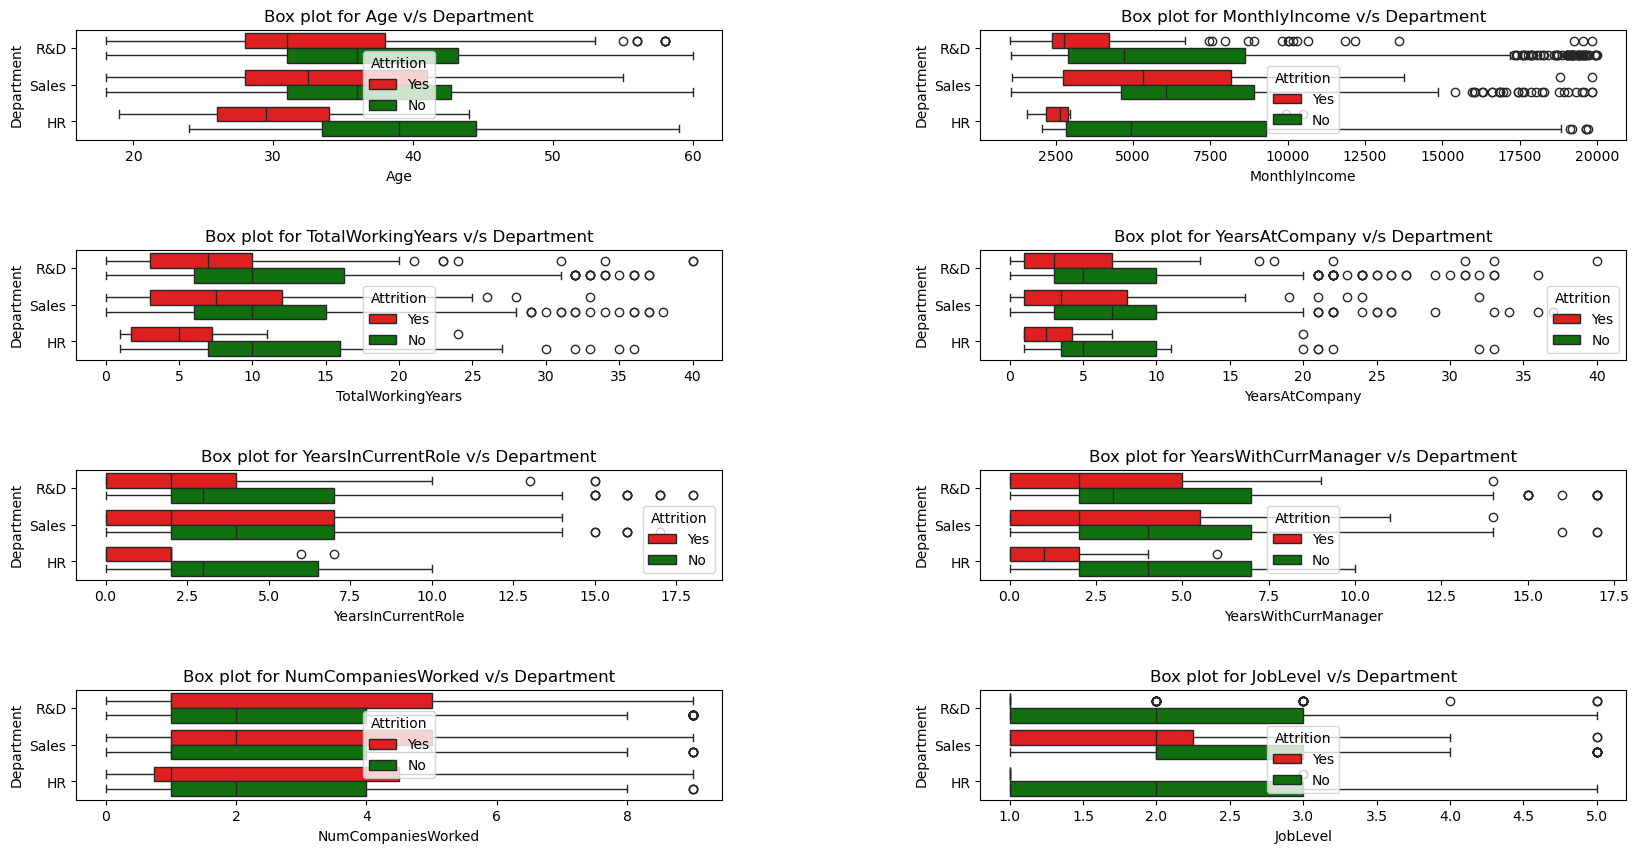

In [66]:
# Box plot for strong_attr_predictors v/s Department with attrition as hue

fig, axes = plt.subplots(4,2, figsize=(20,10))
plt.subplots_adjust(wspace=0.4, hspace=1)
axes = axes.flatten()

strong_attr_predictors = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "NumCompaniesWorked",
    "JobLevel"
]


for ax, feature in zip(axes, strong_attr_predictors):
    sns.boxplot(data = emp_data, x = feature , y = 'Department', order = co_data['Department'].value_counts().index, ax=ax, hue = 'Attrition', palette = {'Yes': 'red', 'No' : 'green'})
    ax.set_title(f'Box plot for {feature} v/s Department')
plt.show()

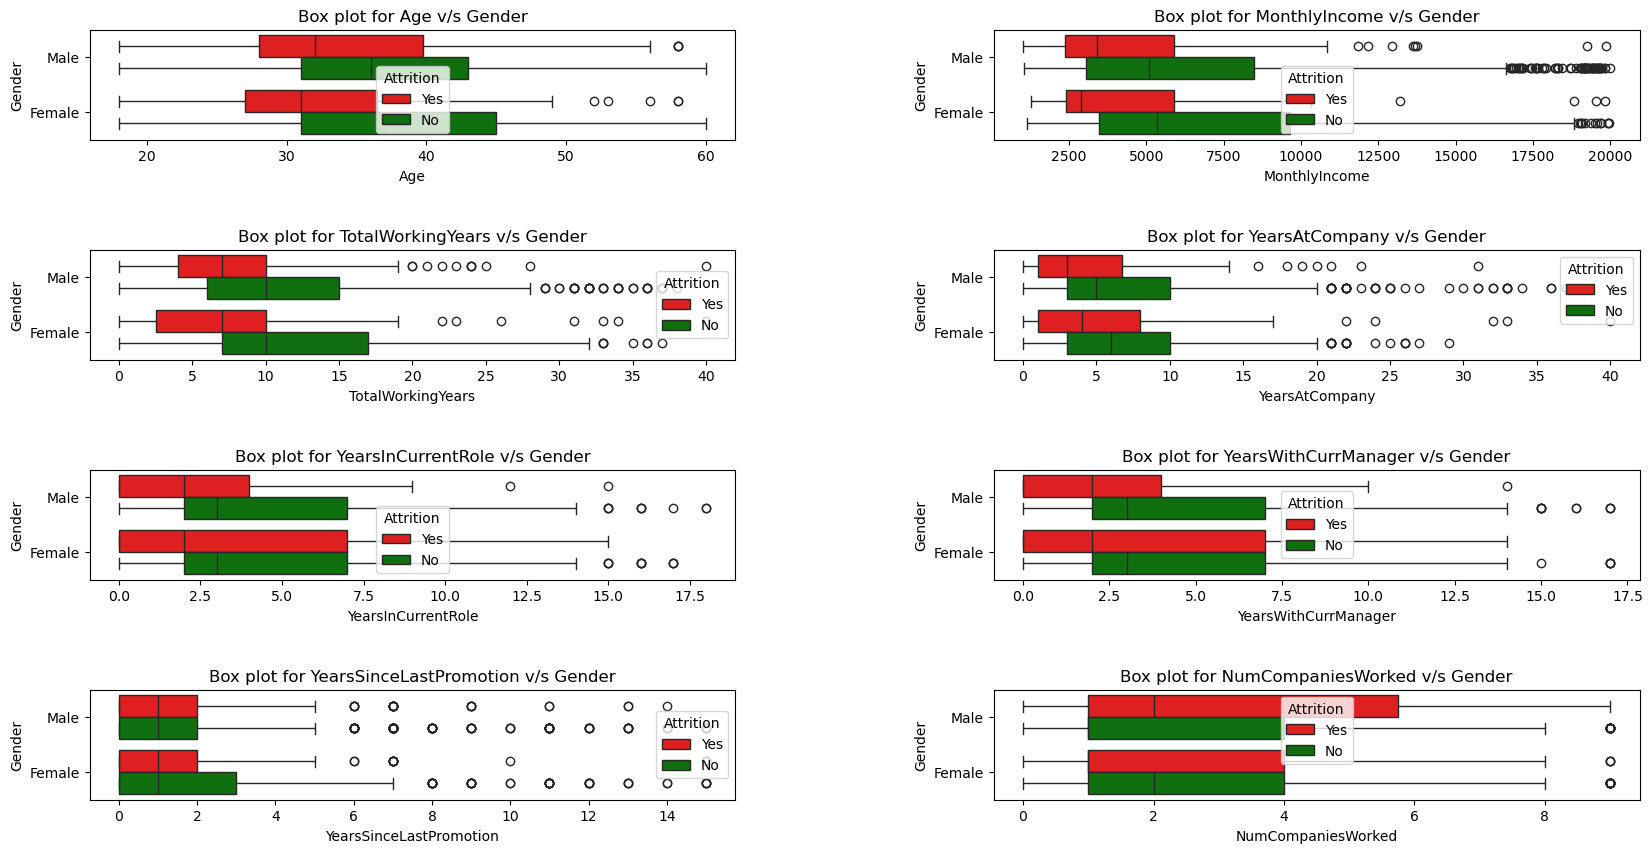

In [65]:
# Box plot for strong_attr_predictors v/s Gender with attrition as hue

fig, axes = plt.subplots(4,2, figsize=(20,10))
plt.subplots_adjust(wspace=0.4, hspace=1)
axes = axes.flatten()
strong_attr_predictors = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "YearsSinceLastPromotion",
    "NumCompaniesWorked",
]


for ax, feature in zip(axes, strong_attr_predictors):
    sns.boxplot(data = emp_data, x = feature , y = 'Gender', order = co_data['Gender'].value_counts().index, ax=ax, hue = 'Attrition', palette = {'Yes': 'red', 'No' : 'green'})
    ax.set_title(f'Box plot for {feature} v/s Gender')
plt.show()

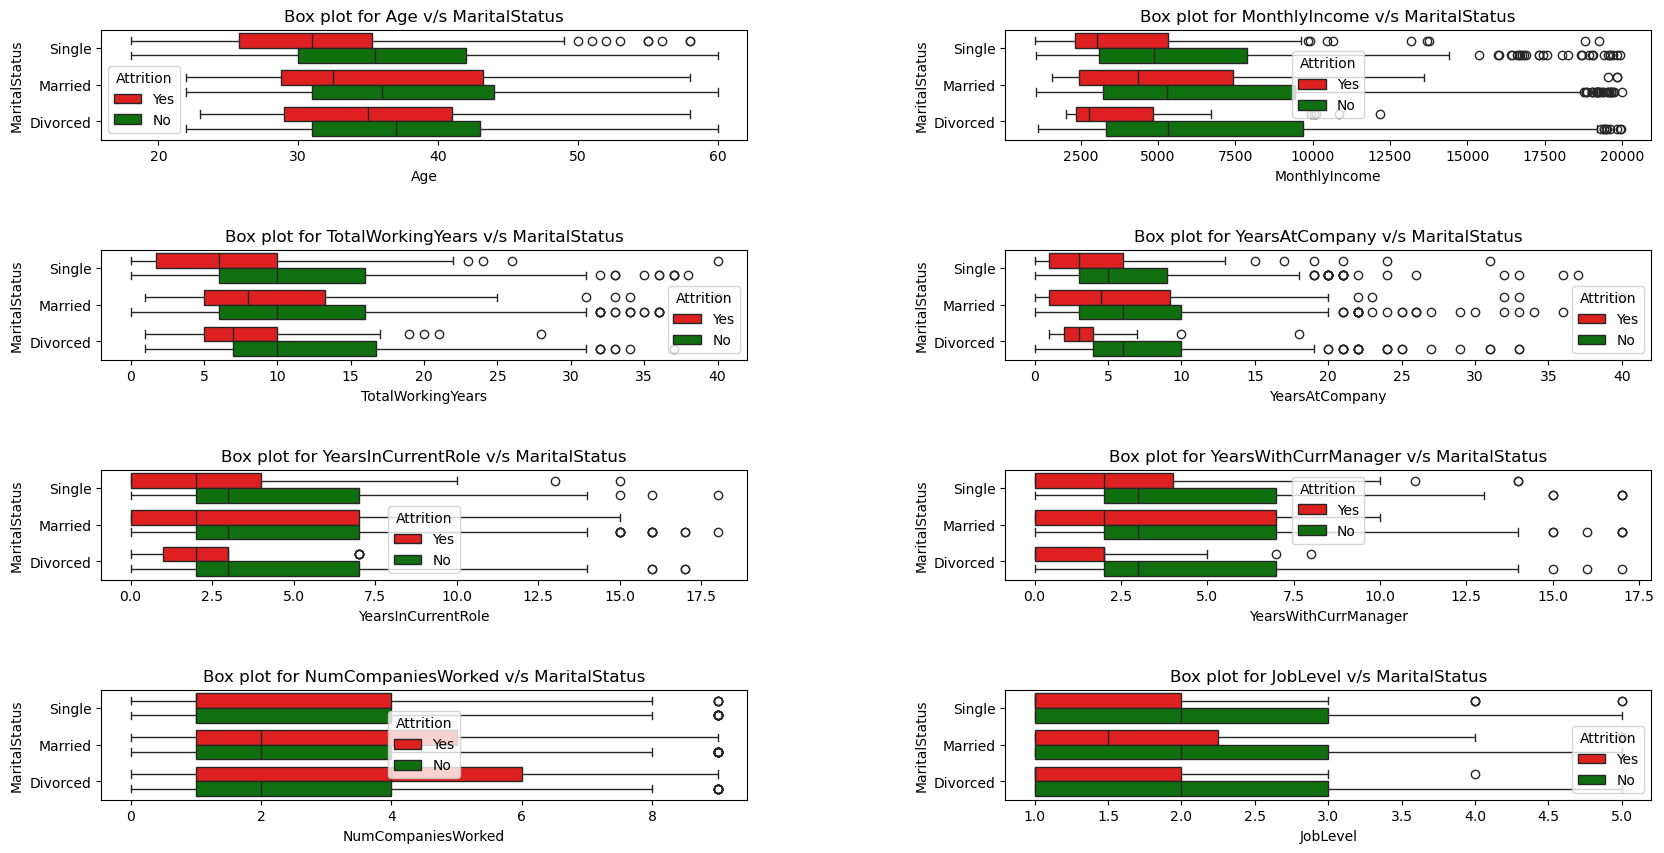

In [67]:
# Box plot for strong_attr_predictors v/s MaritalStatus with attrition as hue

fig, axes = plt.subplots(4,2, figsize=(20,10))
plt.subplots_adjust(wspace=0.4, hspace=1)
axes = axes.flatten()

strong_attr_predictors = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "NumCompaniesWorked",
    "JobLevel"
]


for ax, feature in zip(axes, strong_attr_predictors):
    sns.boxplot(data = emp_data, x = feature , y = 'MaritalStatus', order = co_data['MaritalStatus'].value_counts().index, ax=ax, hue = 'Attrition', palette = {'Yes': 'red', 'No' : 'green'})
    ax.set_title(f'Box plot for {feature} v/s MaritalStatus')
plt.show()

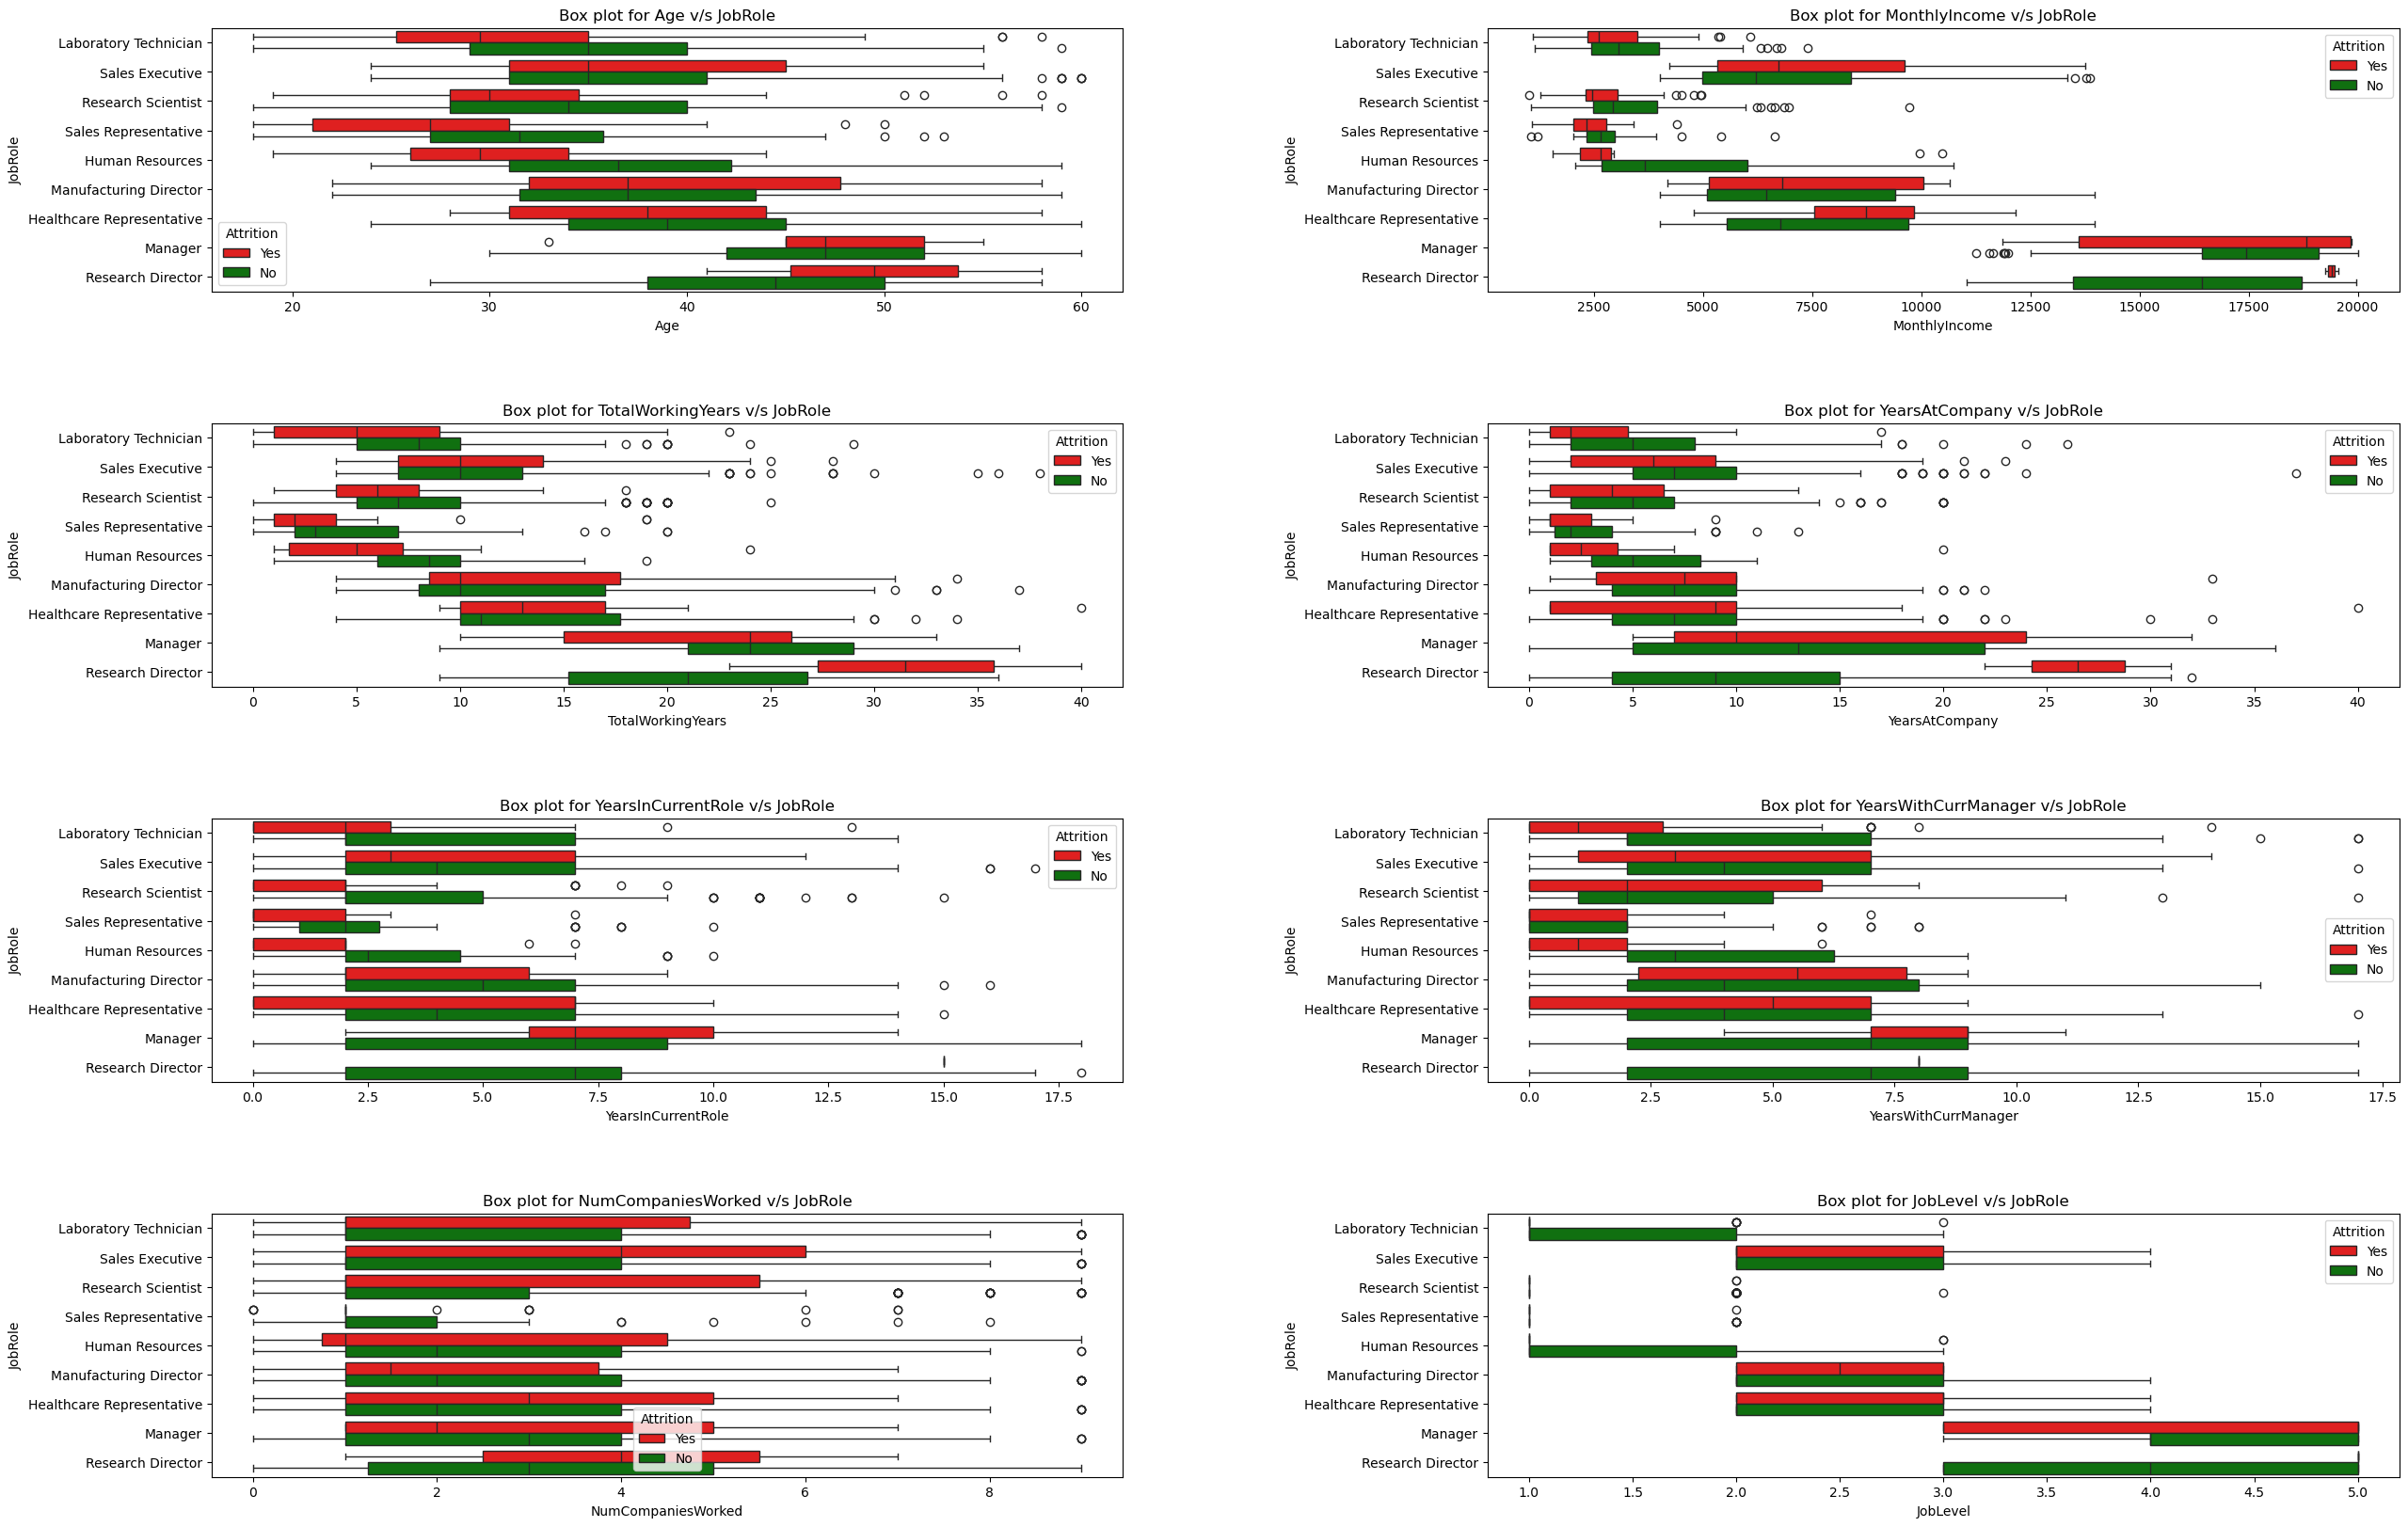

In [58]:
# Box plot for strong_attr_predictors v/s JobRole with attrition as hue

fig, axes = plt.subplots(4,2, figsize=(30,20))
plt.subplots_adjust(wspace=0.4, hspace=0.5)
axes = axes.flatten()

strong_attr_predictors = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "NumCompaniesWorked",
    "JobLevel"
]


for ax, feature in zip(axes, strong_attr_predictors):
    sns.boxplot(data = emp_data, x = feature , y = 'JobRole', order = co_data['JobRole'].value_counts().index, ax=ax, hue = 'Attrition', palette = {'Yes': 'red', 'No' : 'green'})
    ax.set_title(f'Box plot for {feature} v/s JobRole')
plt.show()

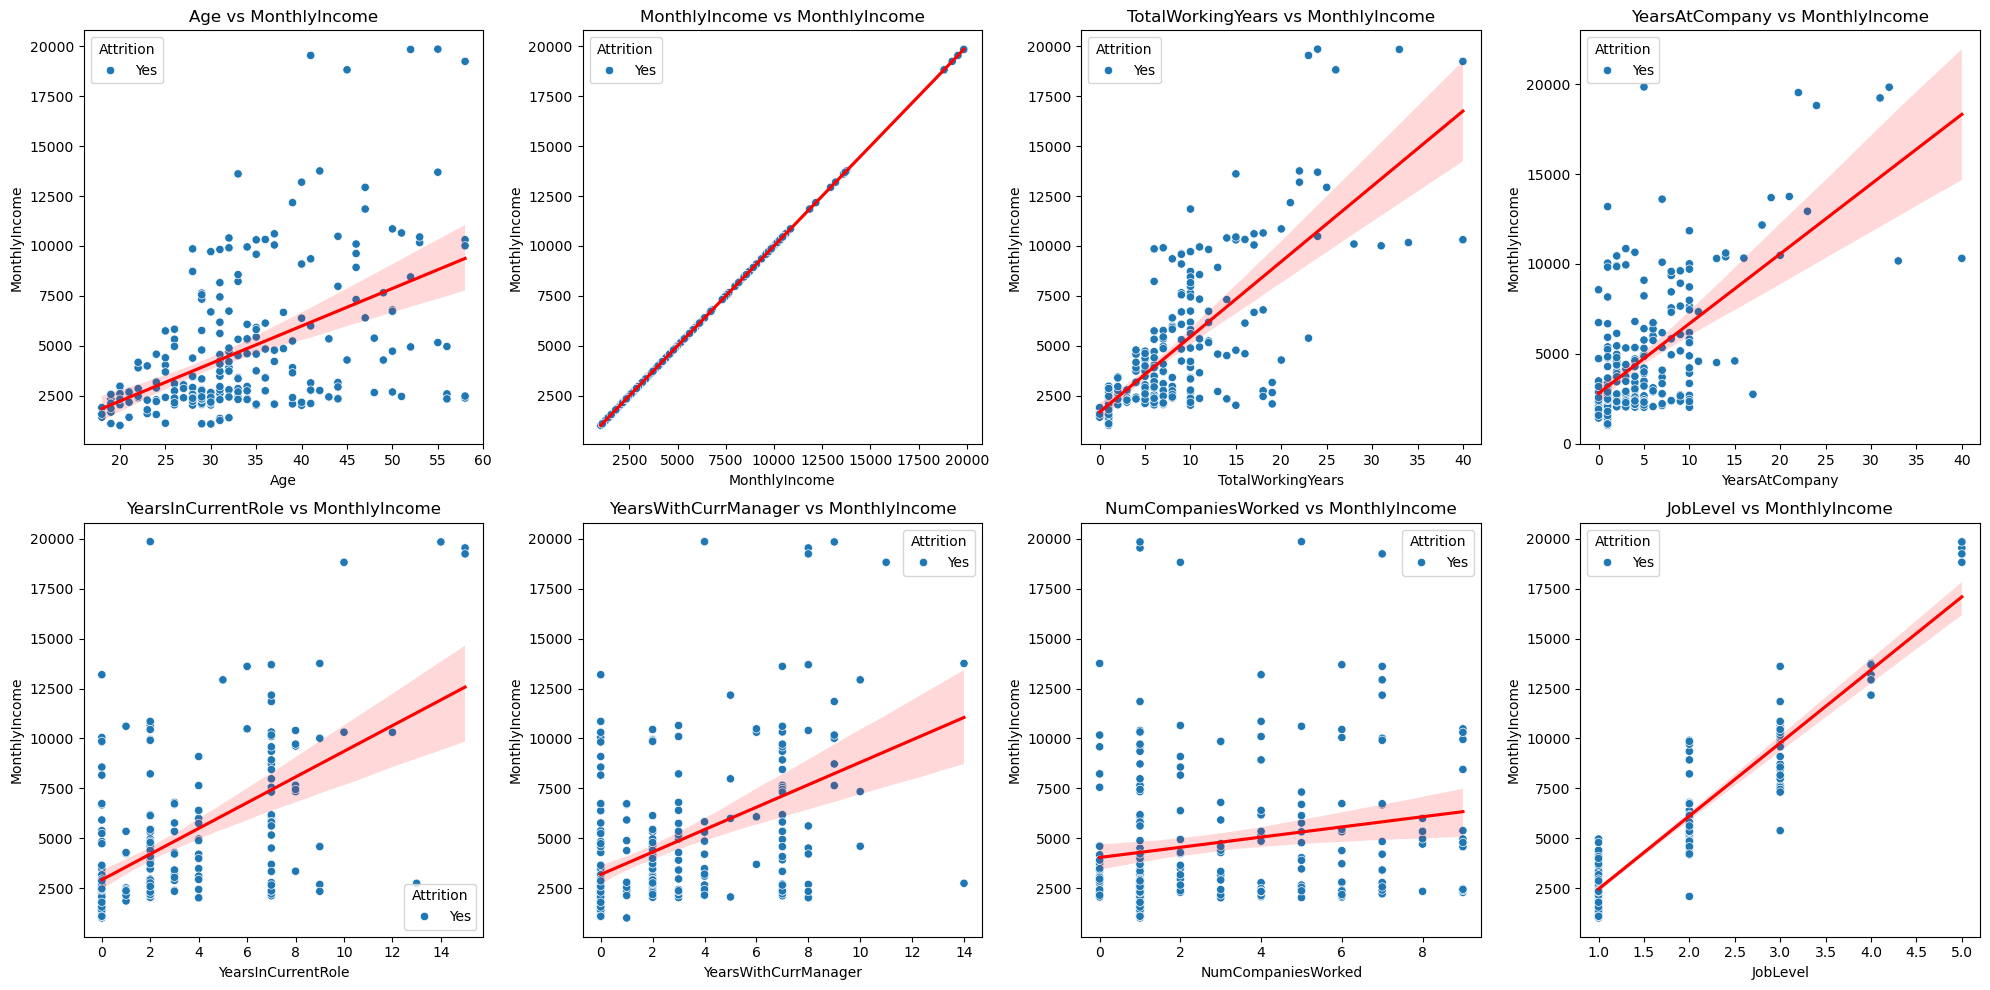

In [71]:
# Try combination of numerical values with respect to hue

fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # Changed to 2x4 for 8 features
plt.subplots_adjust(wspace=0.4, hspace=0.5)
axes = axes.flatten()

strong_attr_predictors = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "NumCompaniesWorked",
    "JobLevel"
]

# Loop through each feature and create a scatterplot in each subplot
for ax, feature in zip(axes, strong_attr_predictors):
    # Create scatterplot for each feature vs MonthlyIncome, colored by Attrition
    sns.scatterplot(
        data=co_data, 
        x=feature, 
        y='MonthlyIncome', 
        hue='Attrition',
        ax=ax
    )
    
    # Add regression line for each attrition group
    sns.regplot(
        data=co_data, 
        x=feature, 
        y='MonthlyIncome',
        scatter=False,
        ax=ax,
        color='red'
    )
    
    ax.set_title(f'{feature} vs MonthlyIncome')

plt.tight_layout()
plt.show()